In [192]:
import pickle as pkl
pkl.dump(catModel,open('catModel.pkl','wb'))
pkl.dump(Transformer,open("Transformer.pkl",'wb'))
pkl.dump(encoder,open("encoder.pkl",'wb'))

In [46]:
import pandas as pd
import numpy as np
import numpy as np
import xgboost
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
# from 
from sklearn.preprocessing import PowerTransformer,LabelEncoder,StandardScaler,OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
# from sklearn.
from sklearn.metrics import confusion_matrix,recall_score,accuracy_score,precision_score,classification_report
import seaborn as sns


In [47]:
studentOutcome=pd.read_csv("Student Outcome dataset.csv")

In [48]:
studentOutcome.columns=studentOutcome.columns.str.replace('\t','',regex=False)

In [49]:
# checking null values
studentOutcome.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [50]:
# checking datatypes
studentOutcome.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [51]:
# describe
studentOutcome.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [52]:
# extract numerical columns
numCols=[num for num in studentOutcome.columns if studentOutcome[num].dtype!="object"]
textCols=[text for text in studentOutcome.columns if studentOutcome[text].dtype not in ["int64","float64"]]

In [53]:
textCols

['Target']

C:\Users\Bi\AppData\Local\Temp\ipykernel_8912\3756529388.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20,4))


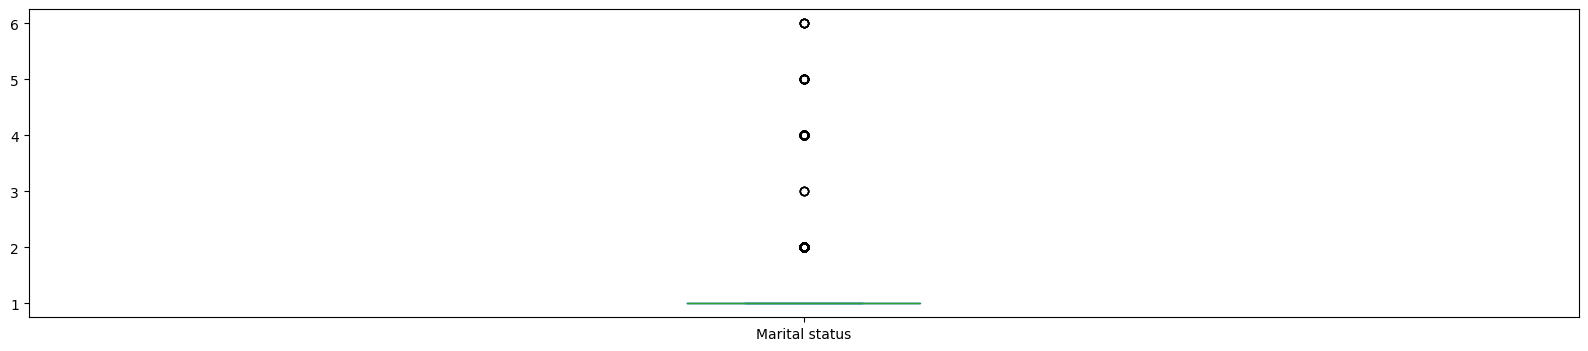

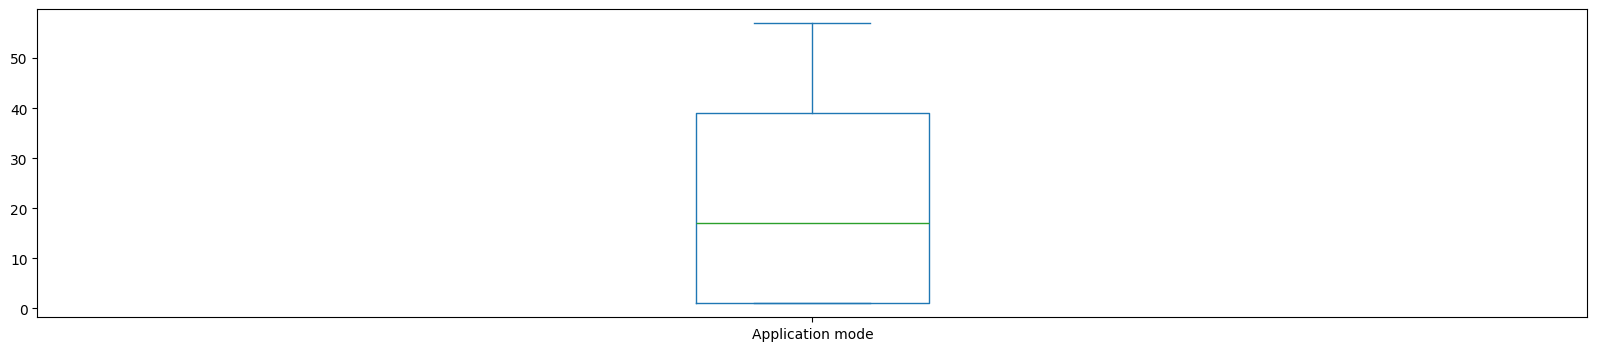

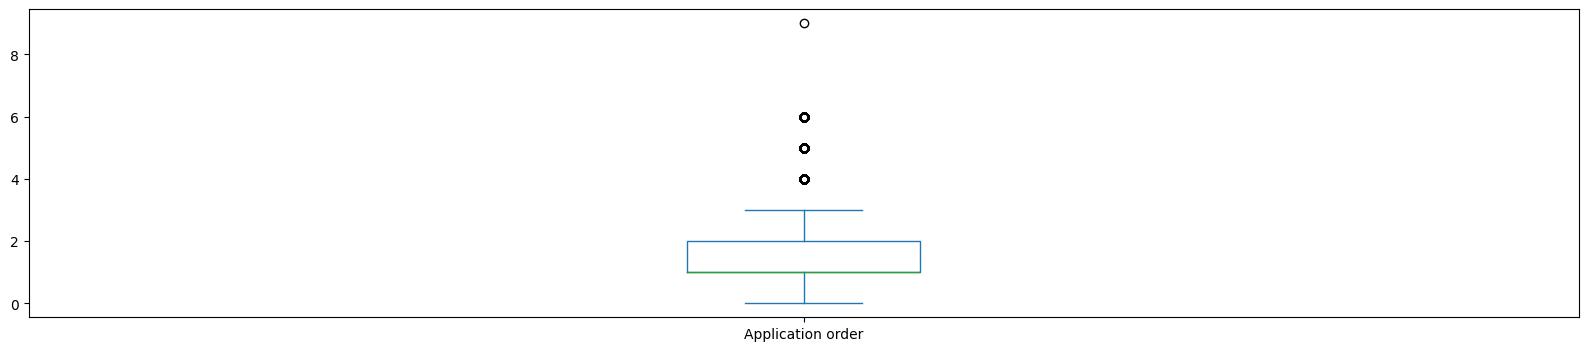

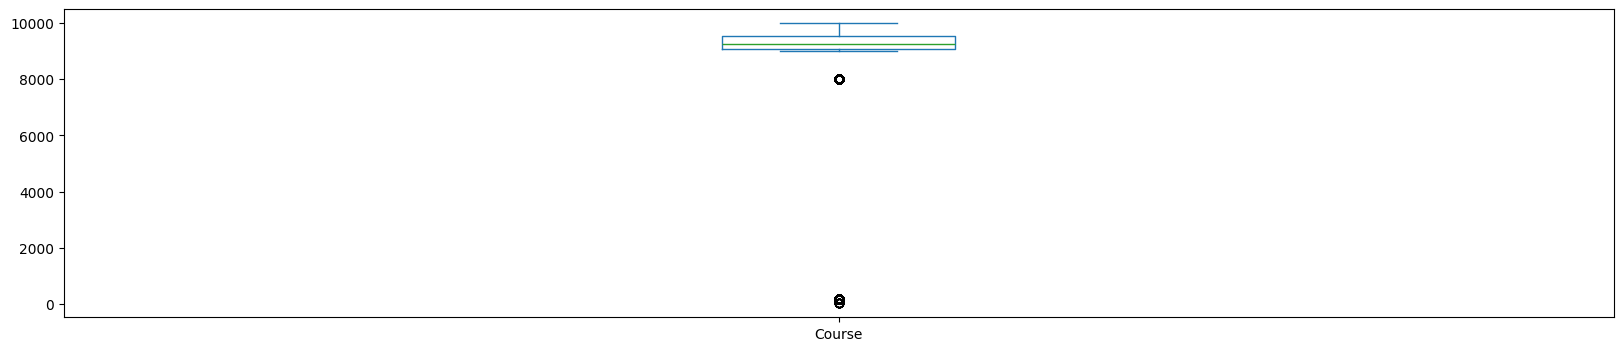

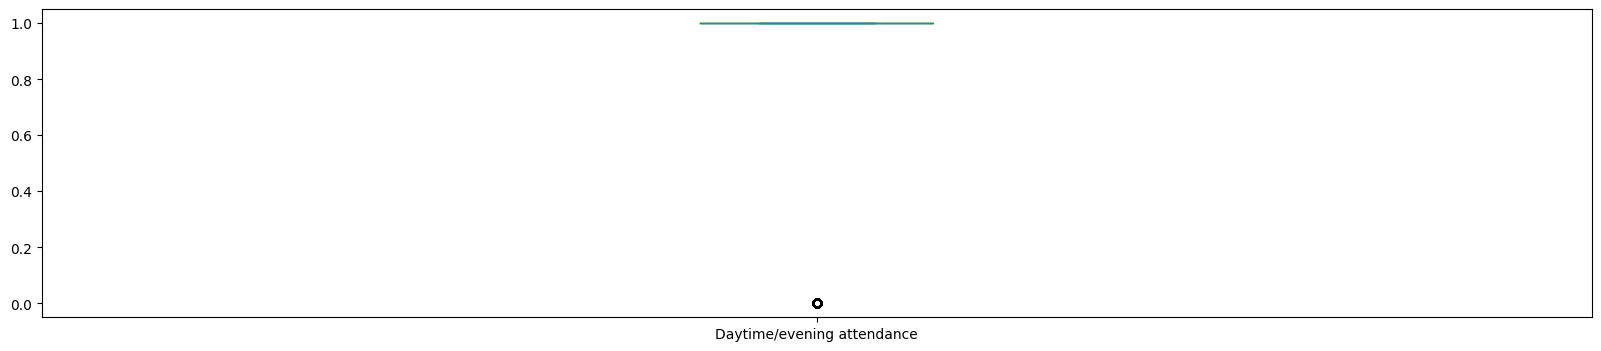

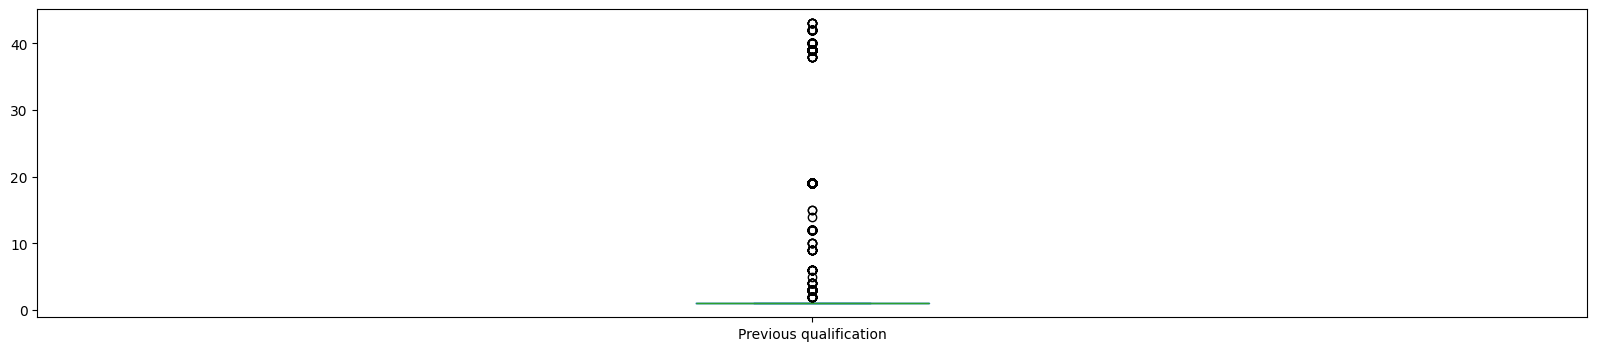

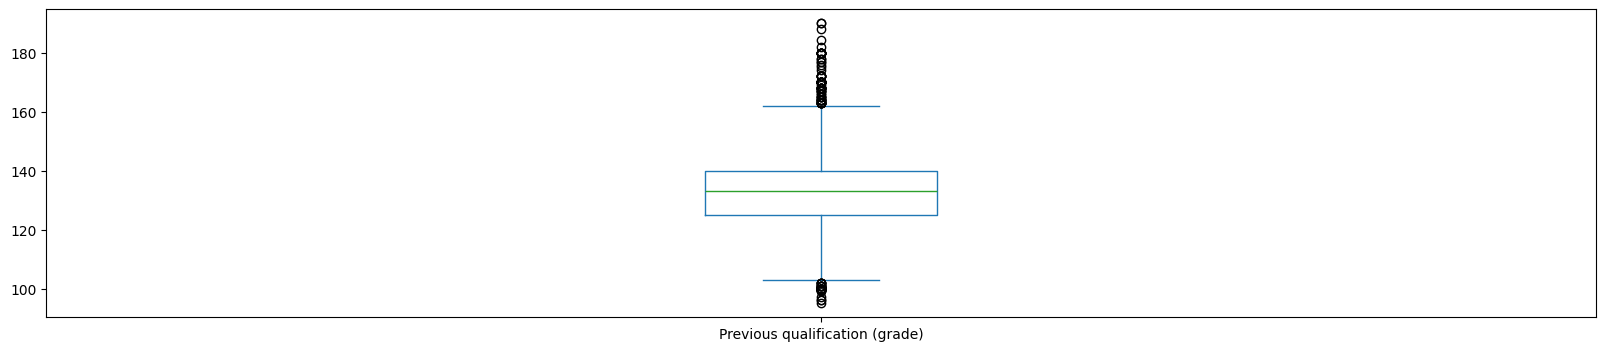

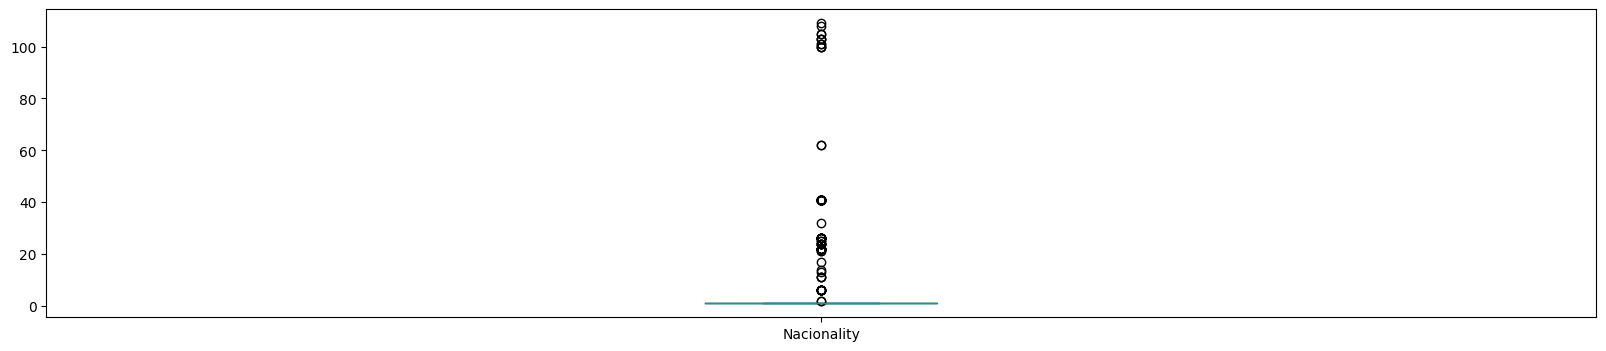

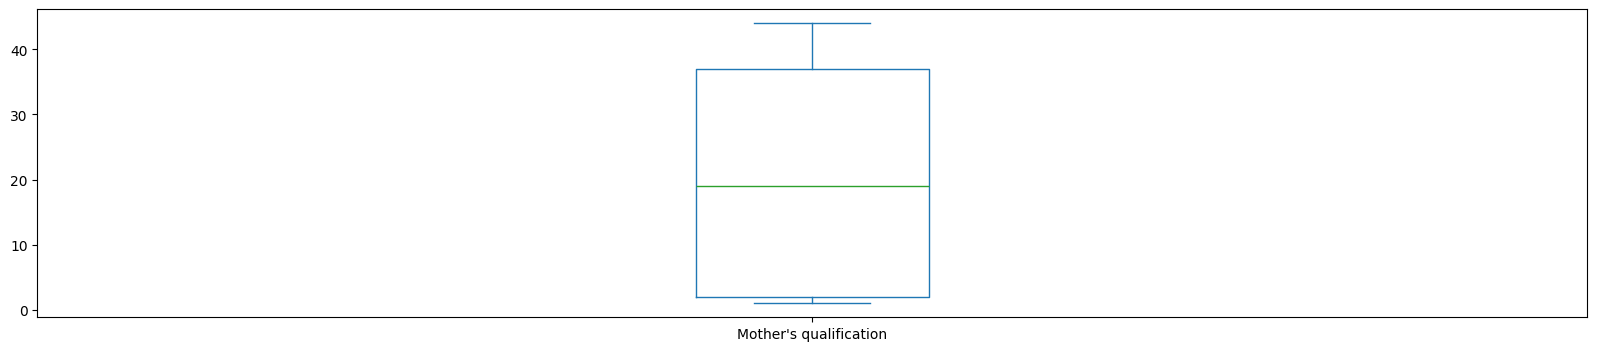

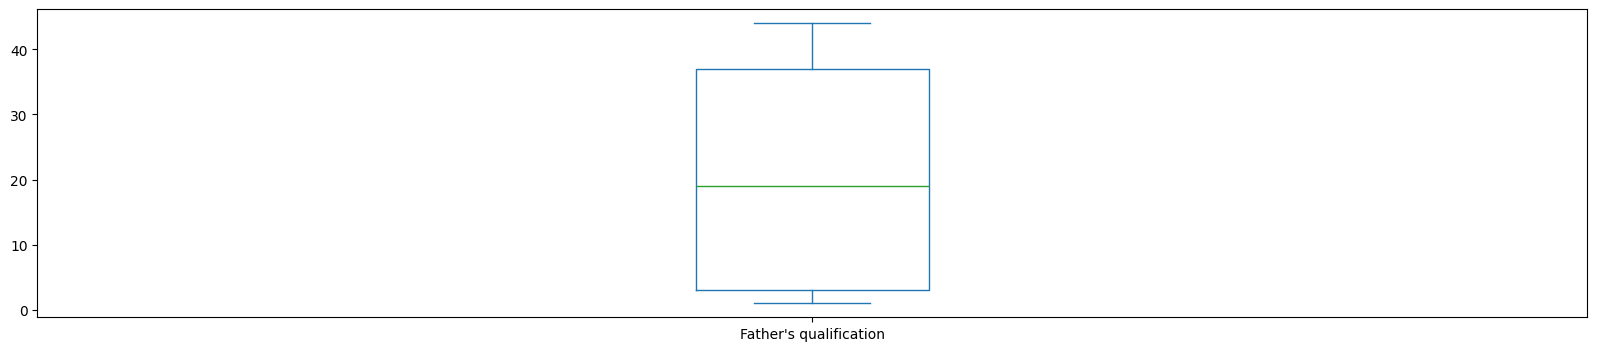

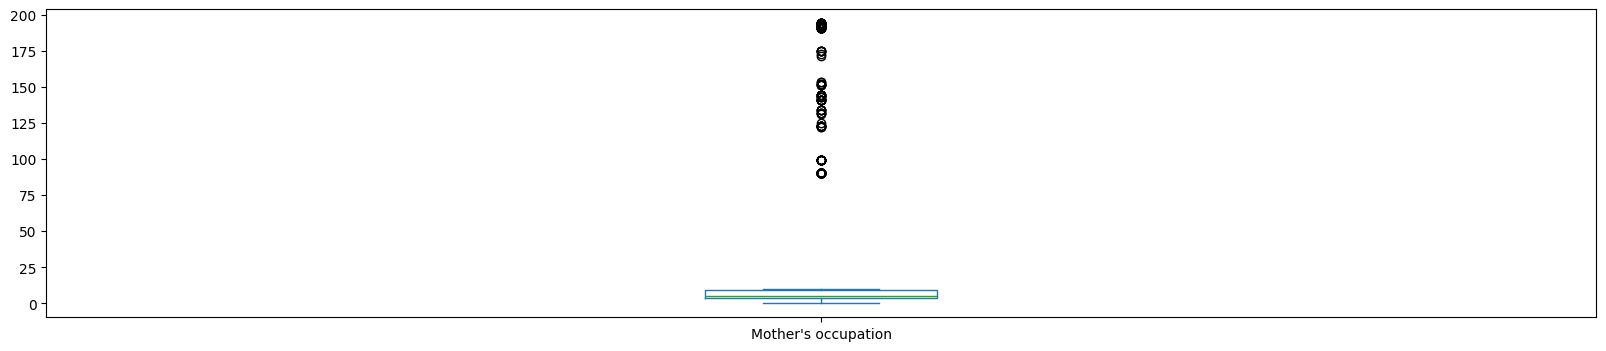

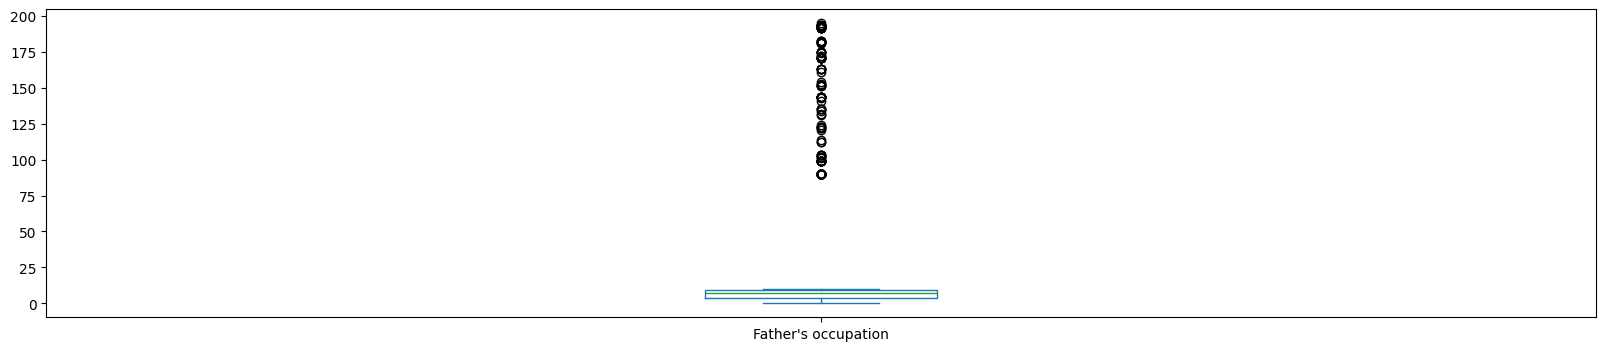

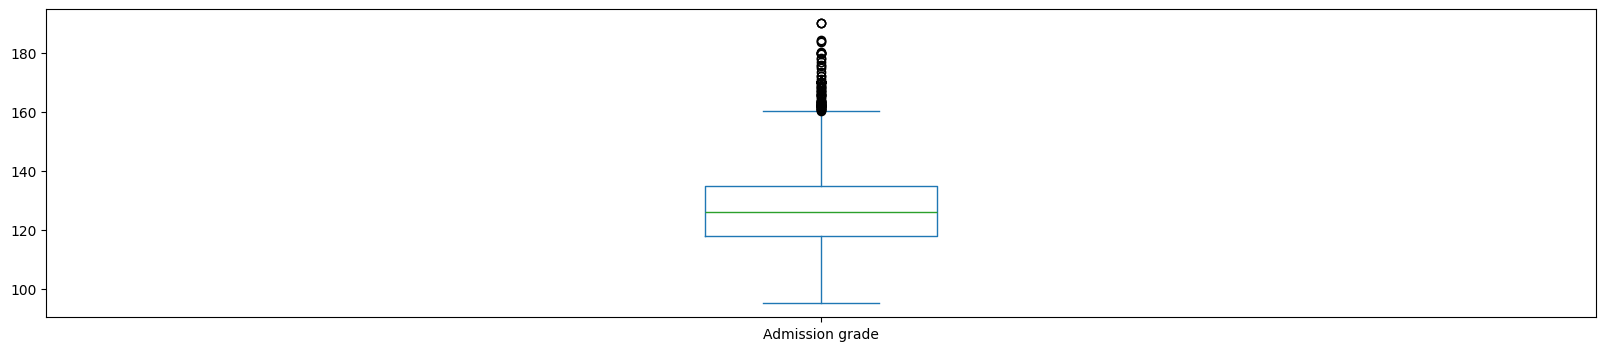

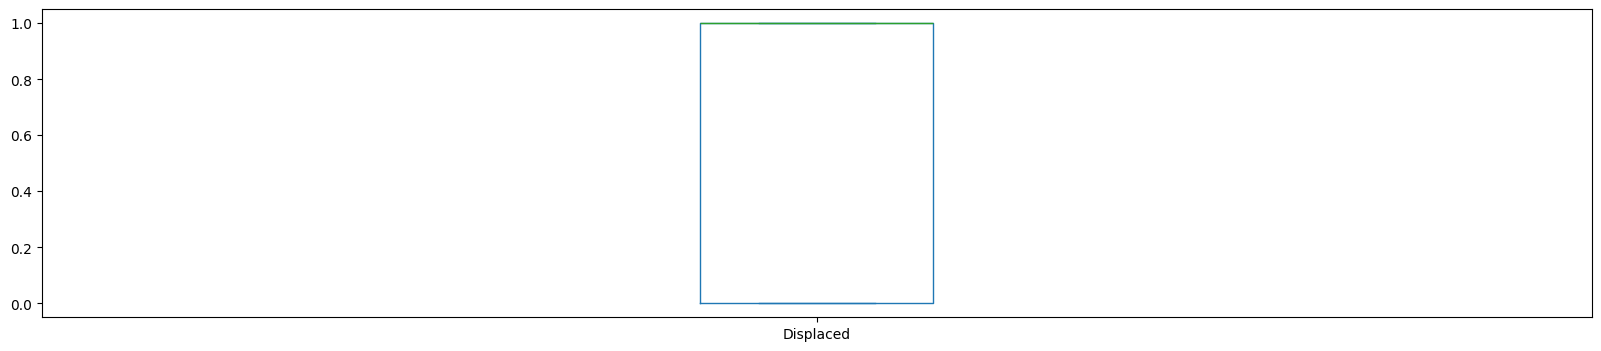

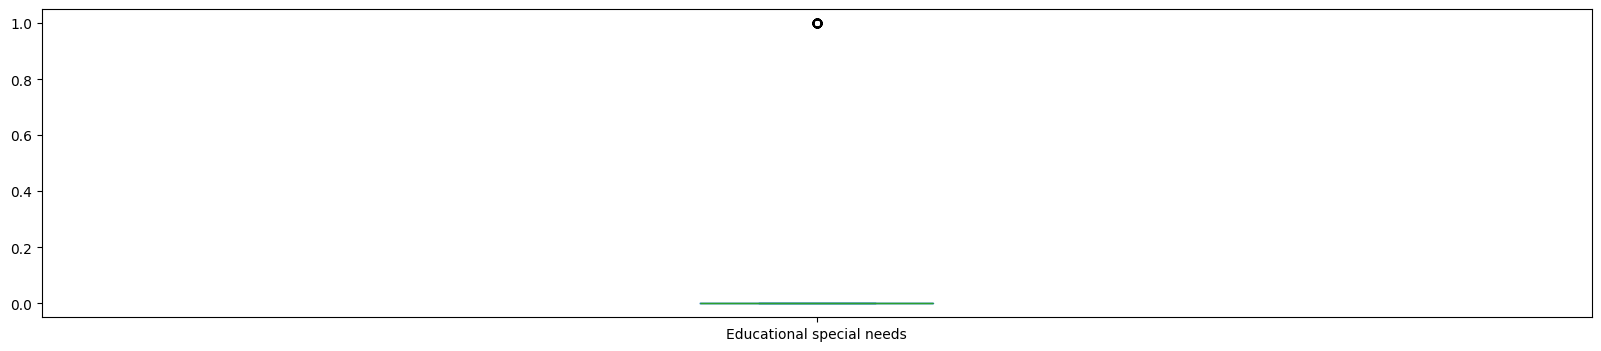

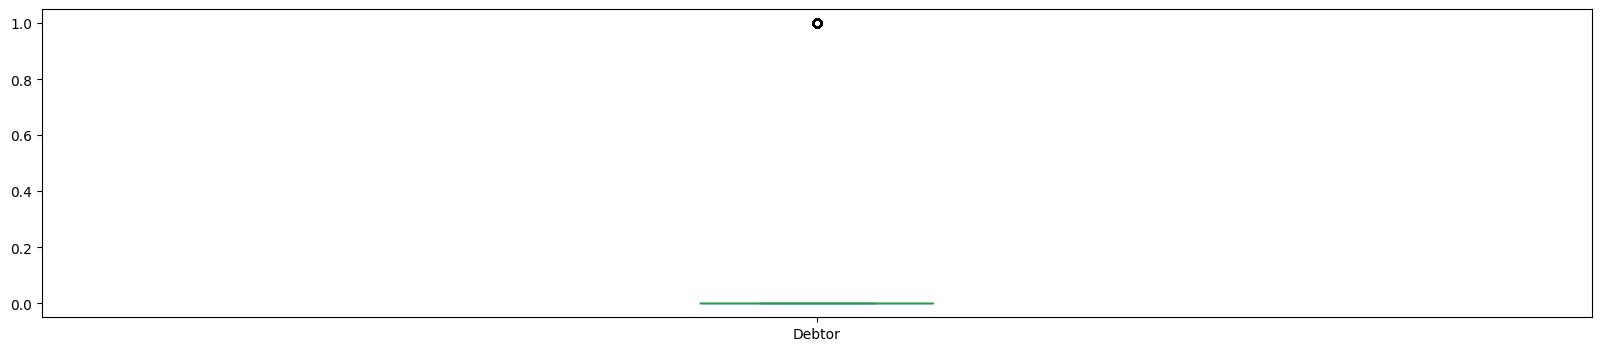

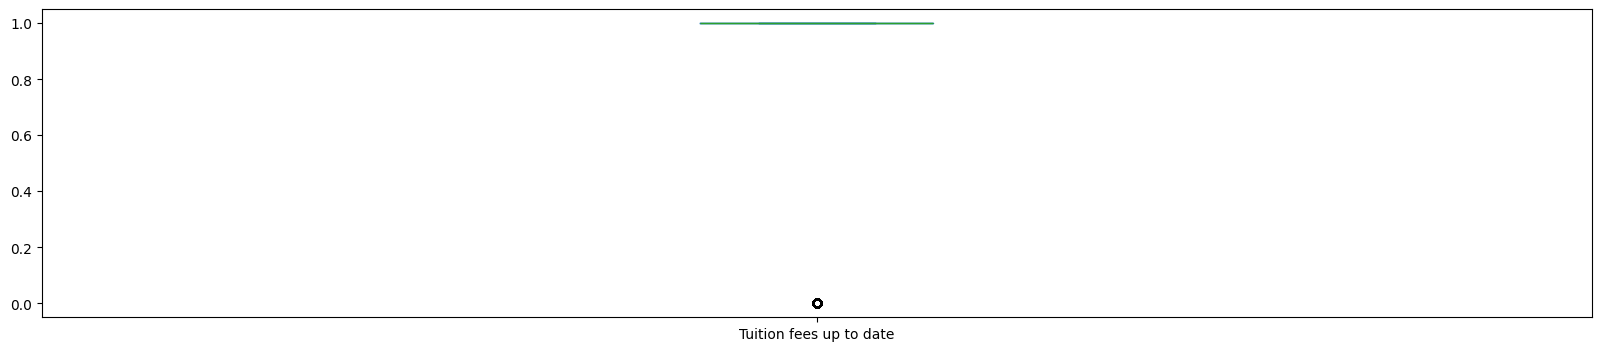

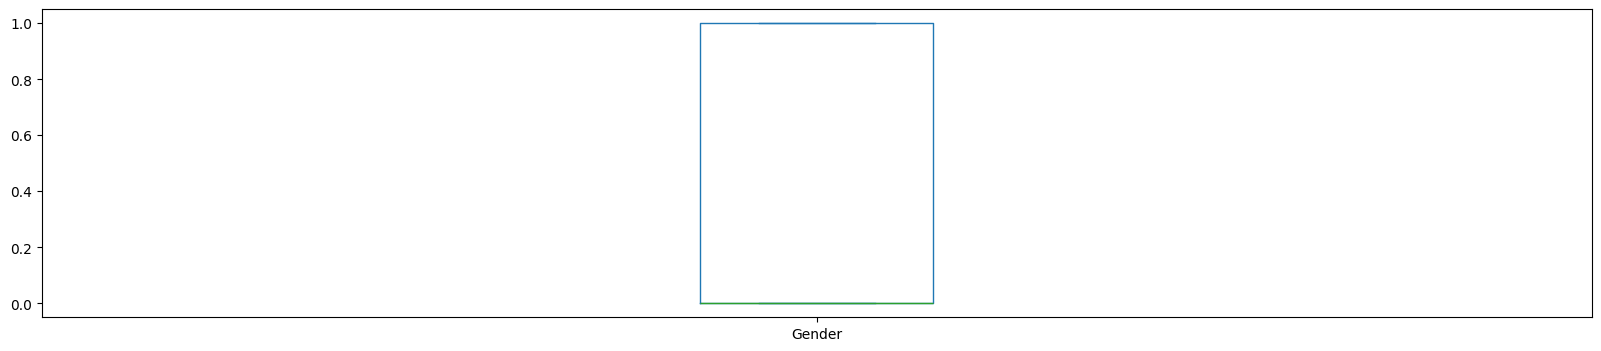

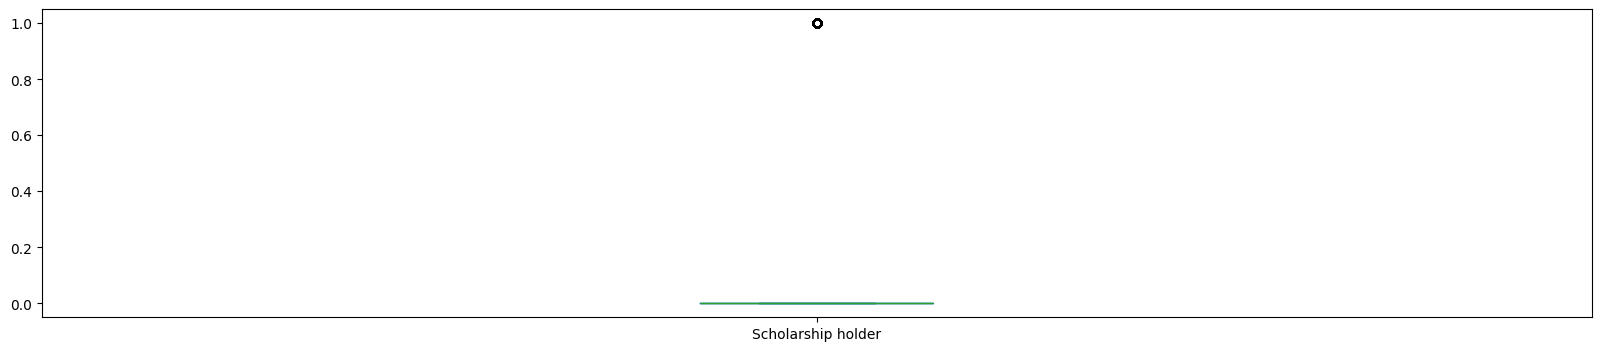

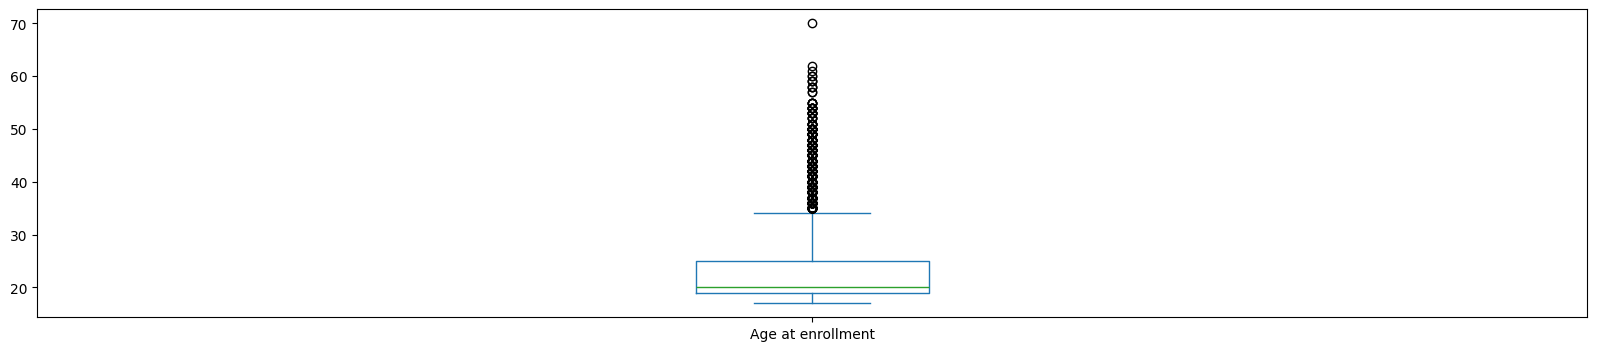

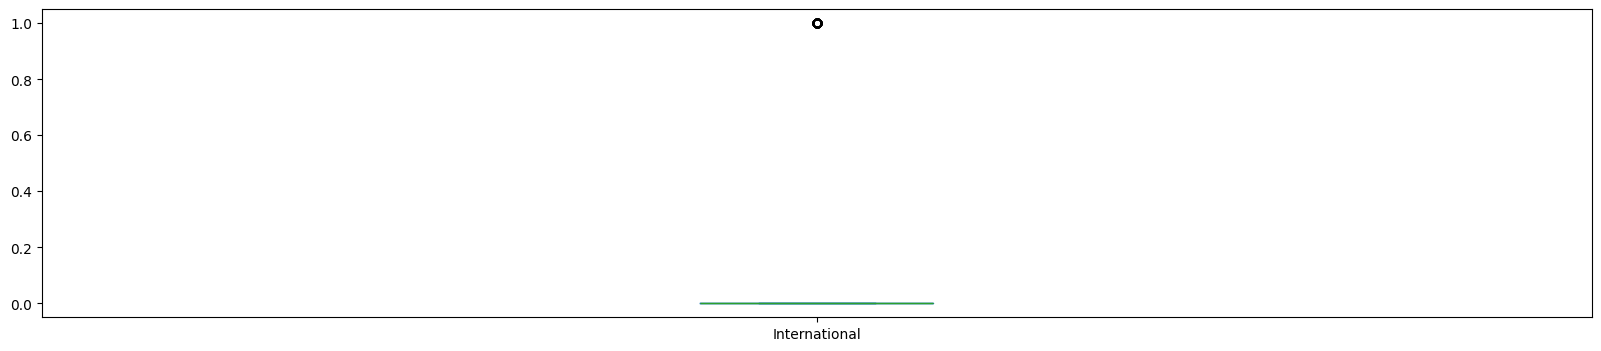

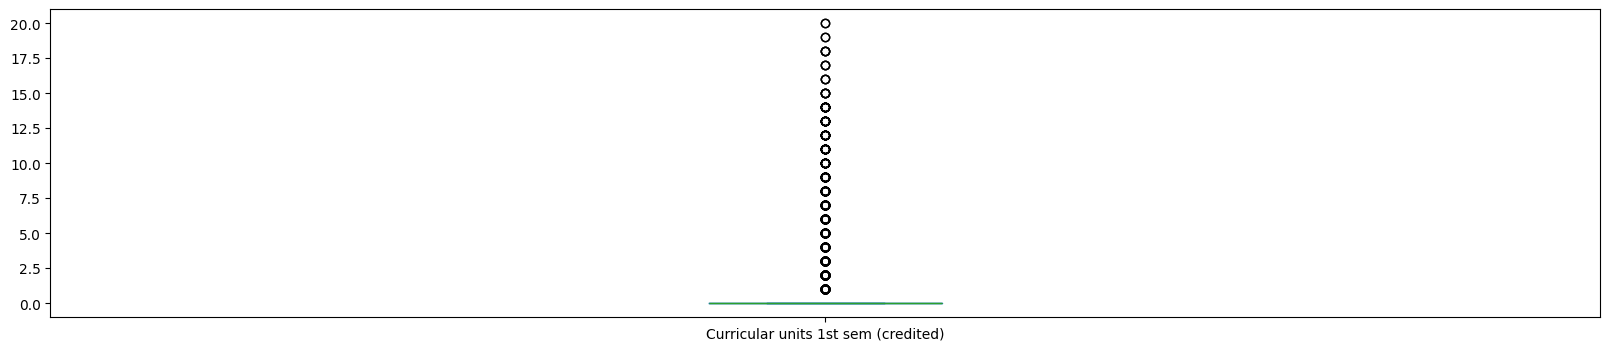

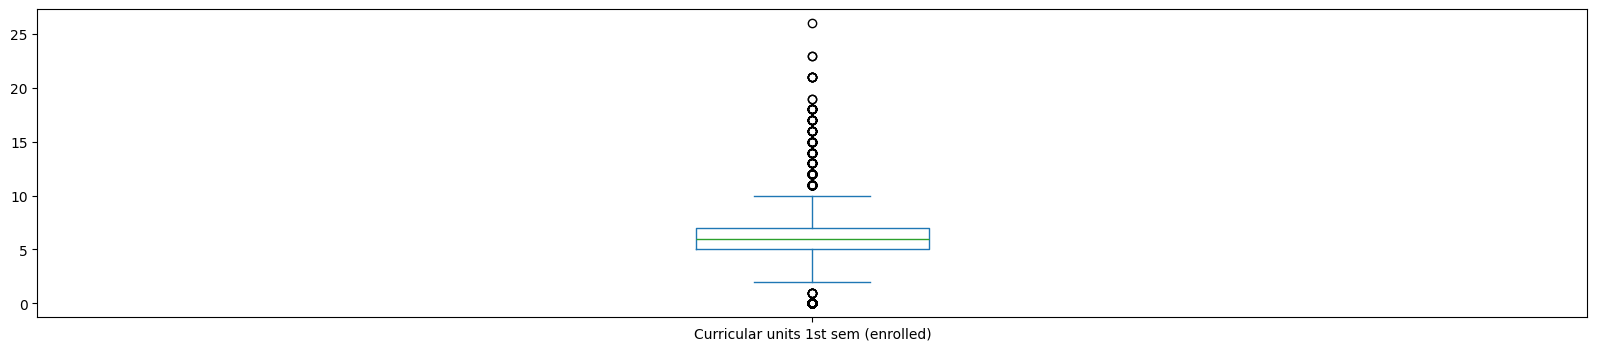

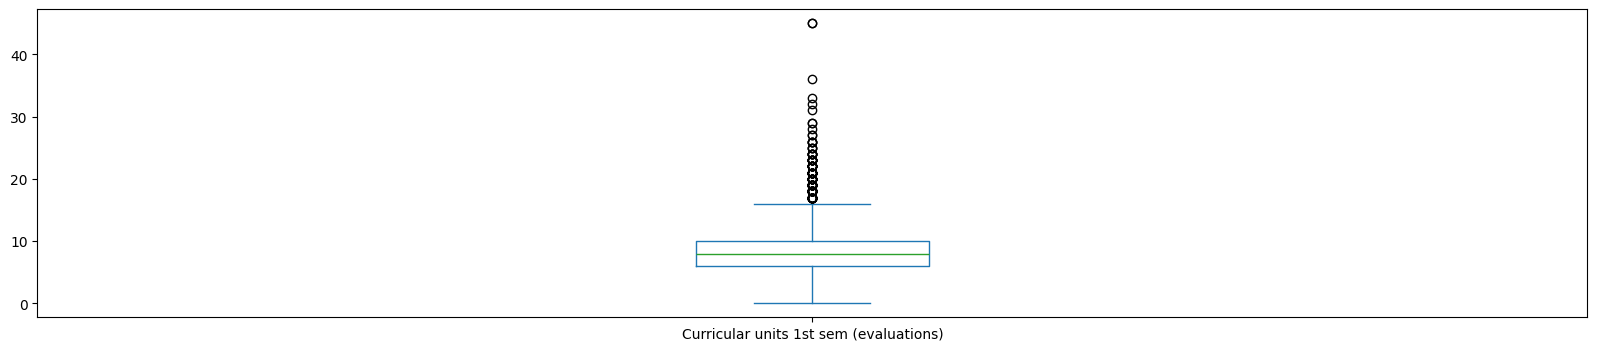

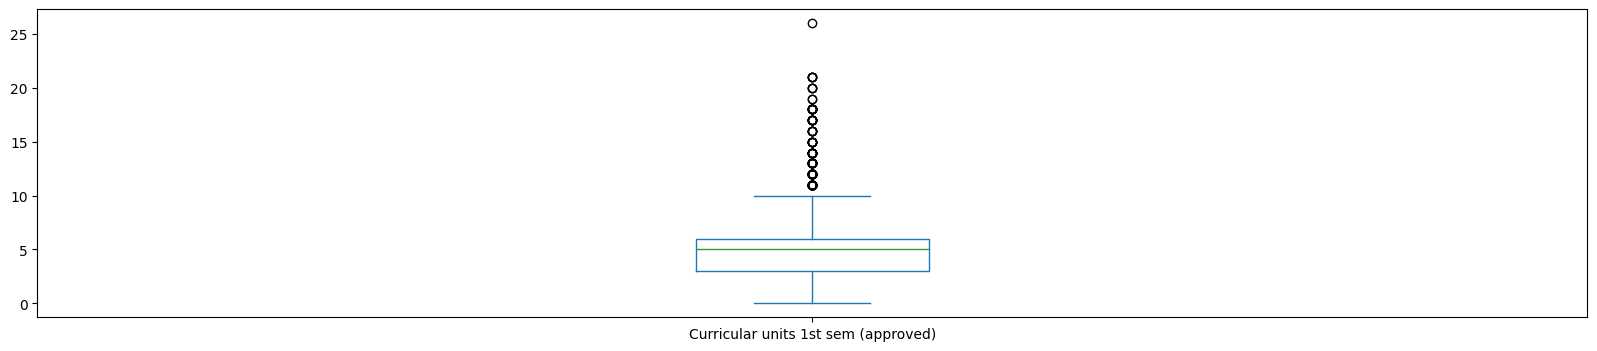

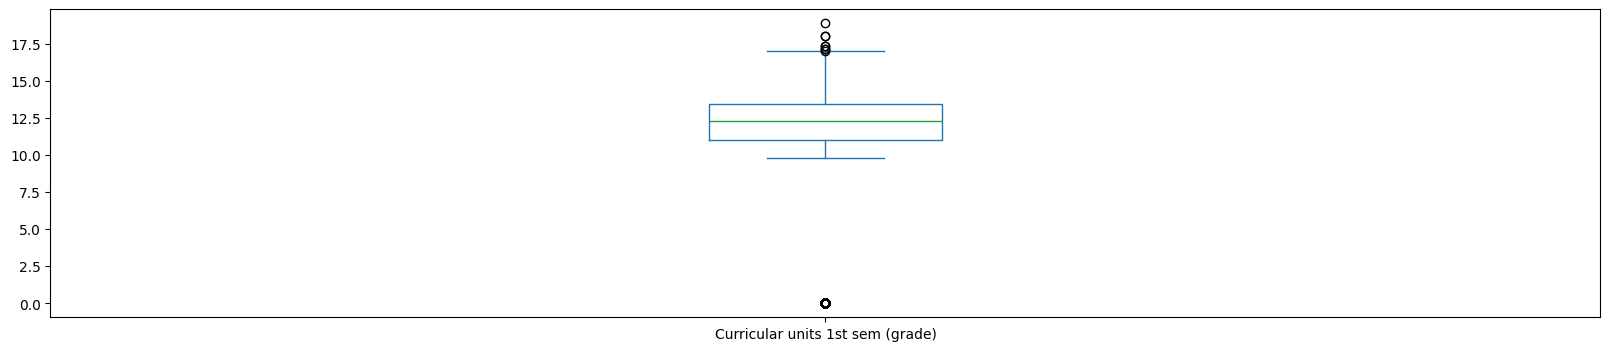

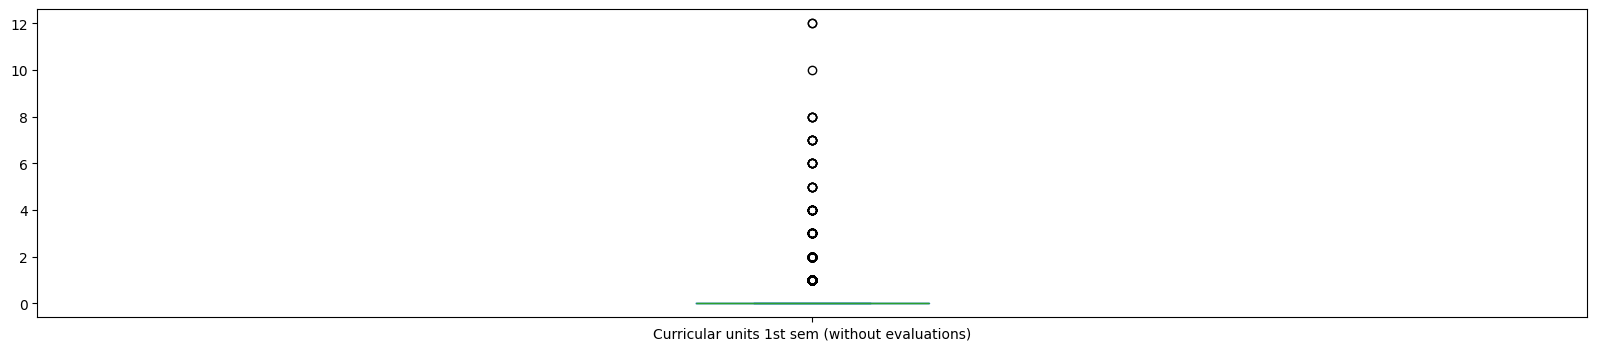

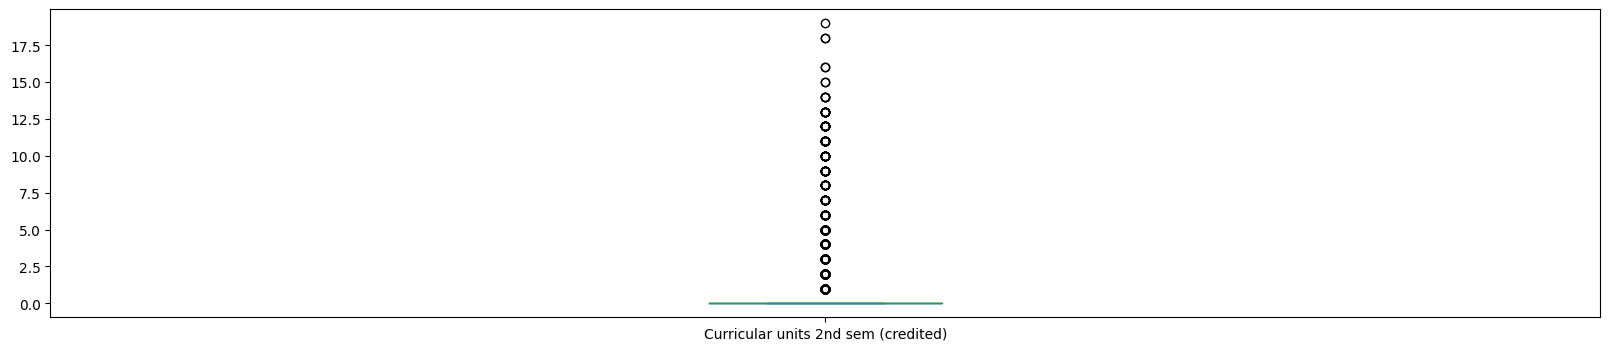

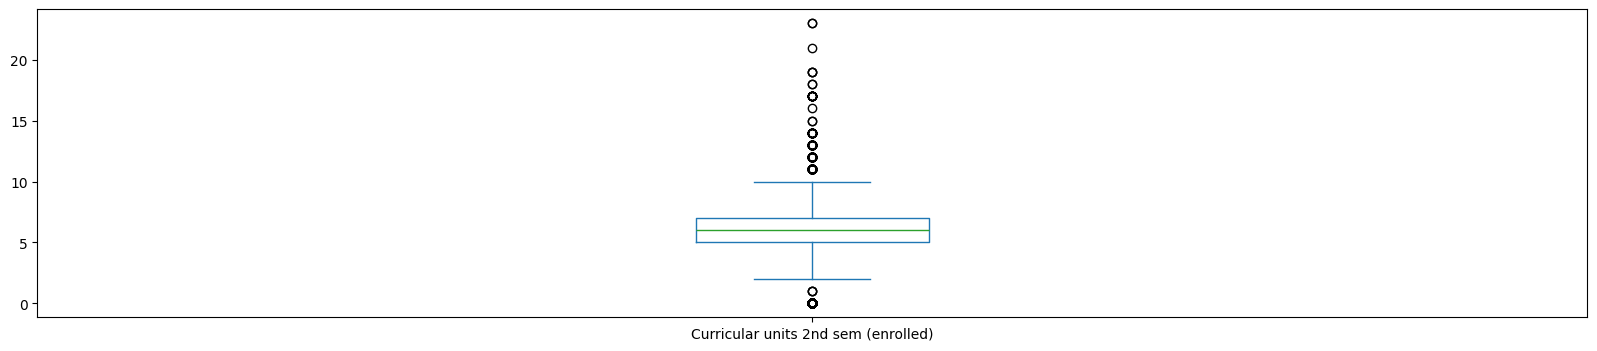

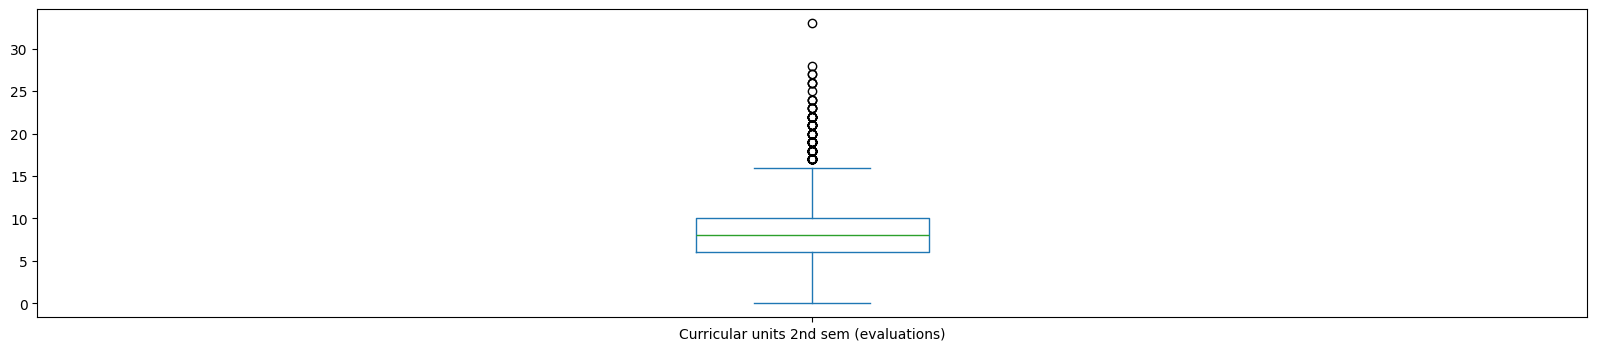

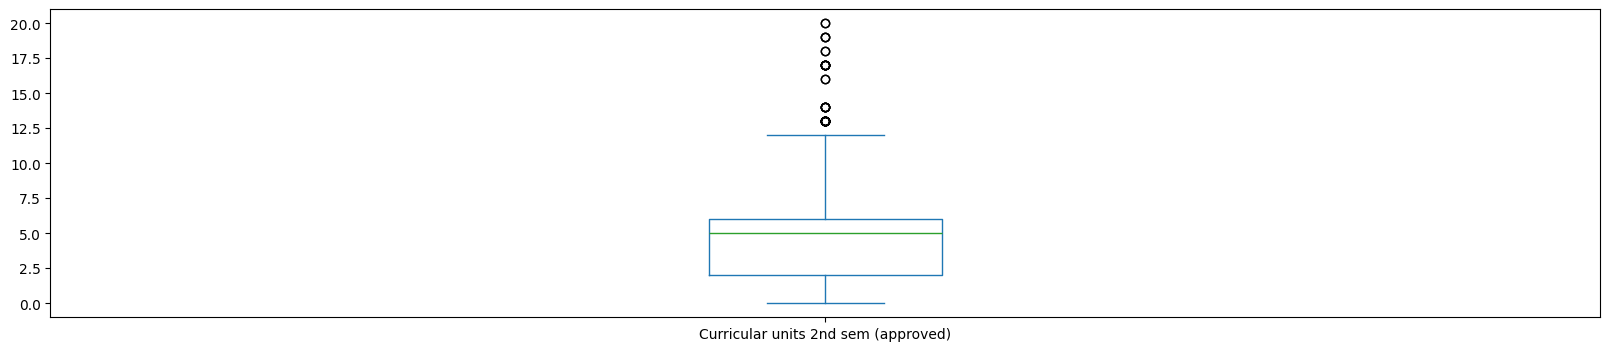

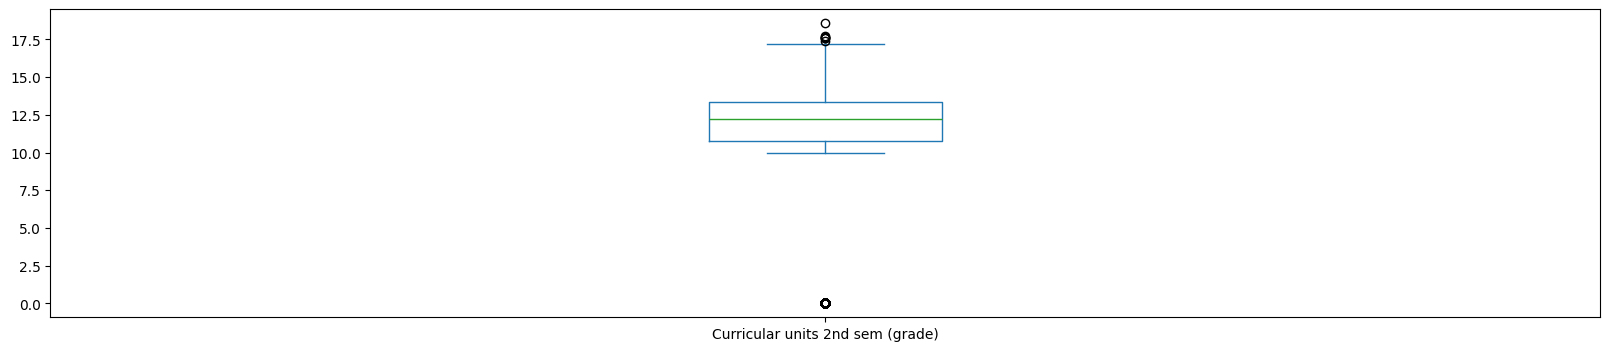

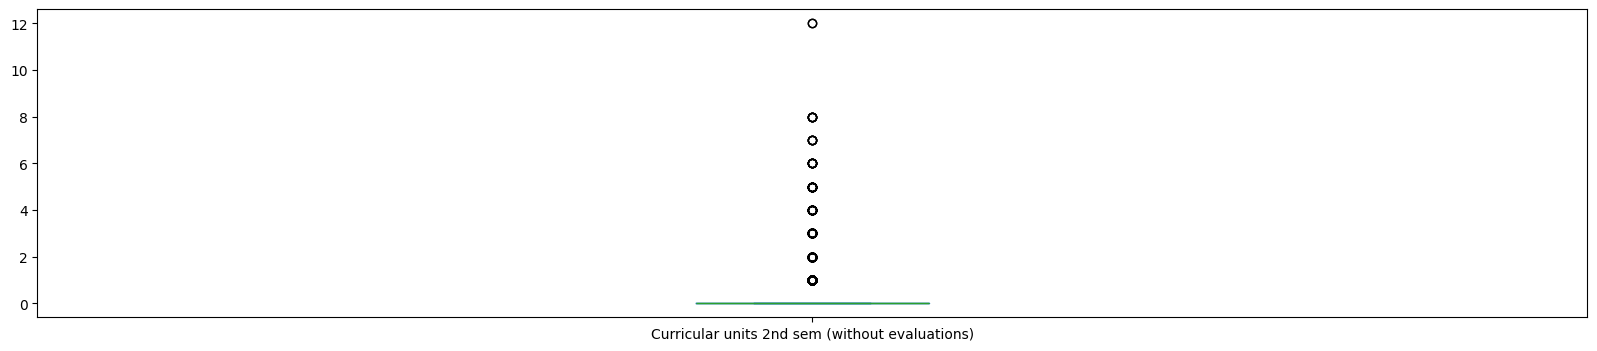

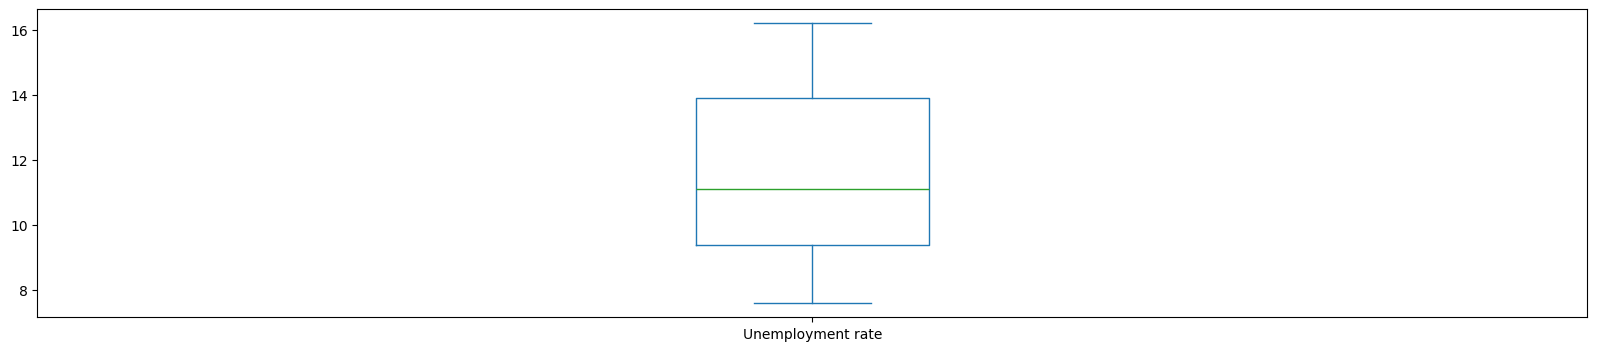

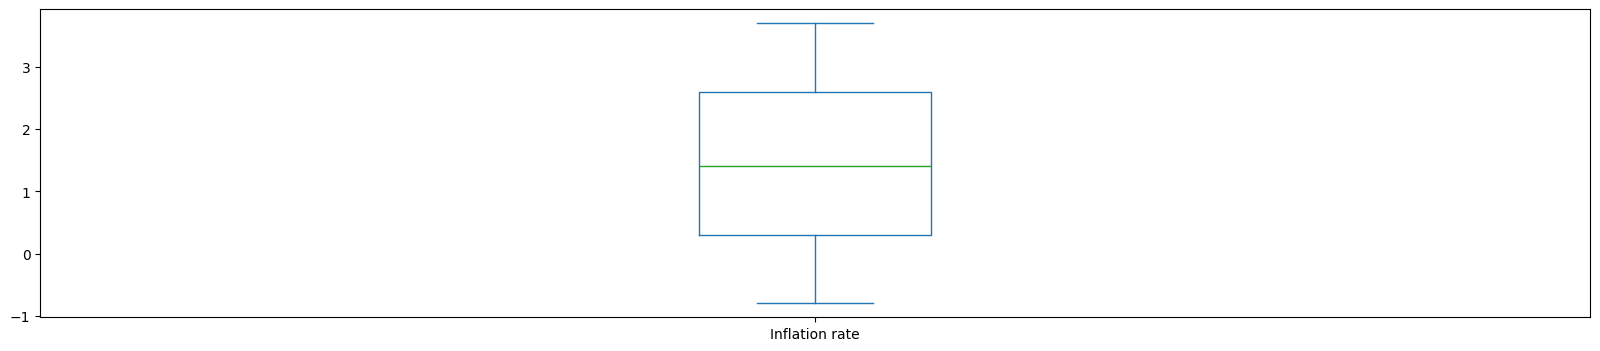

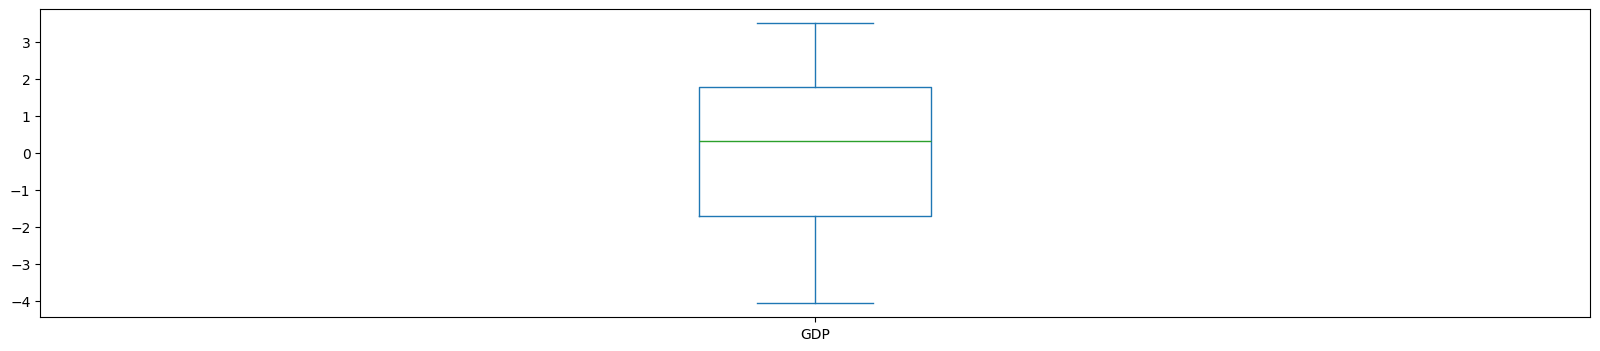

In [54]:
for box in numCols:
    plt.figure(figsize=(20,4))
    studentOutcome[box].plot(kind="box")

In [40]:
for col in studentOutcome.columns:
    if studentOutcome[col].dtype != "object":
        Q1 = studentOutcome[col].quantile(0.25)
        Q3 = studentOutcome[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        has_outliers = (
            (studentOutcome[col] < lower_bound) | 
            (studentOutcome[col] > upper_bound)
        ).any()

        if has_outliers:
            studentOutcome[col] = studentOutcome[col].clip(lower=lower_bound, upper=upper_bound)

In [41]:
for cols in studentOutcome.columns:
    if studentOutcome[cols].dtype!="object":
        Q1=studentOutcome[cols].quantile(0.25)
        Q3=studentOutcome[cols].quantile(0.75)
        IQR=Q3-Q1
        
        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR
        
        count=studentOutcome.loc[(studentOutcome[cols]<Lower) | (studentOutcome[cols]>Upper)].shape[0]
        print(count)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


C:\Users\Bi\AppData\Local\Temp\ipykernel_8912\3756529388.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20,4))


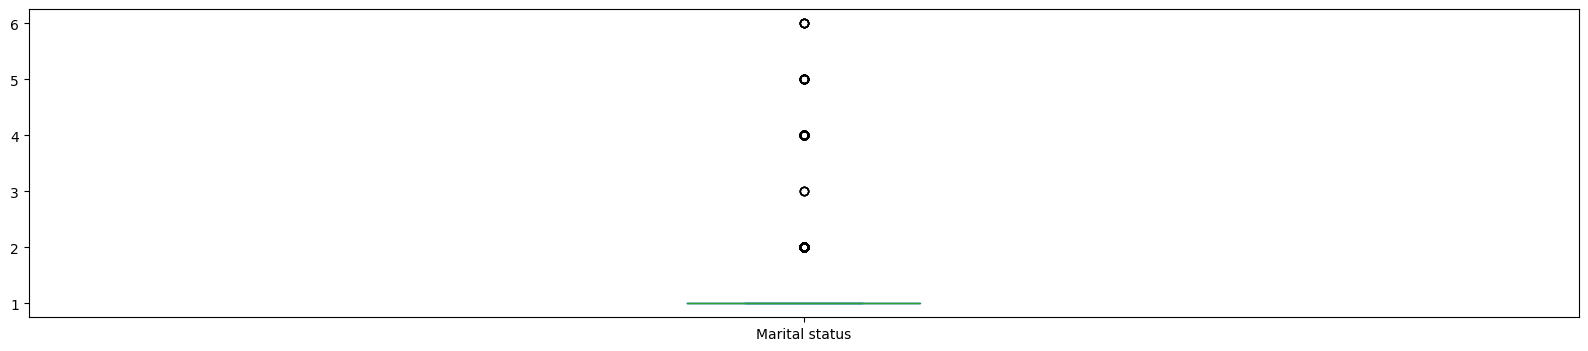

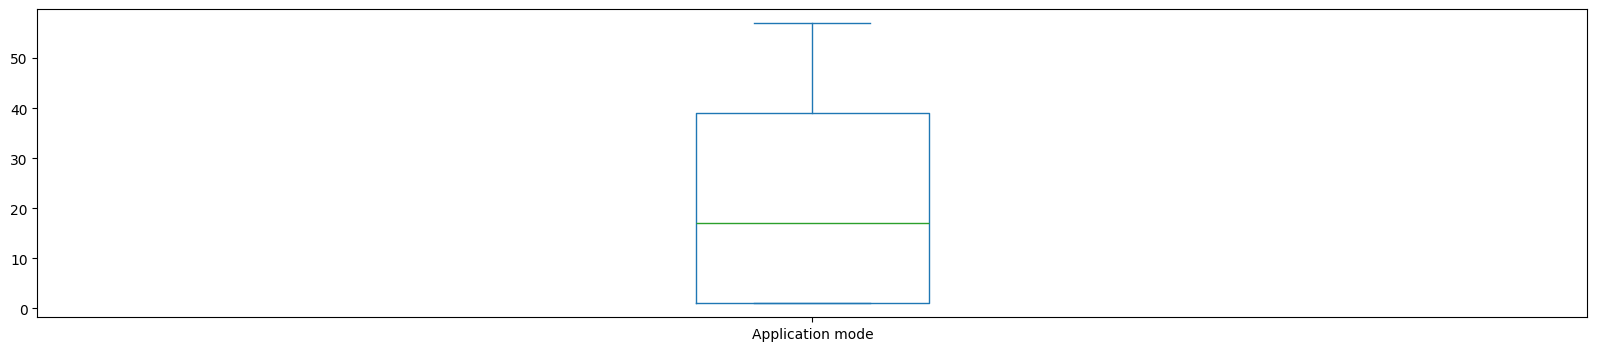

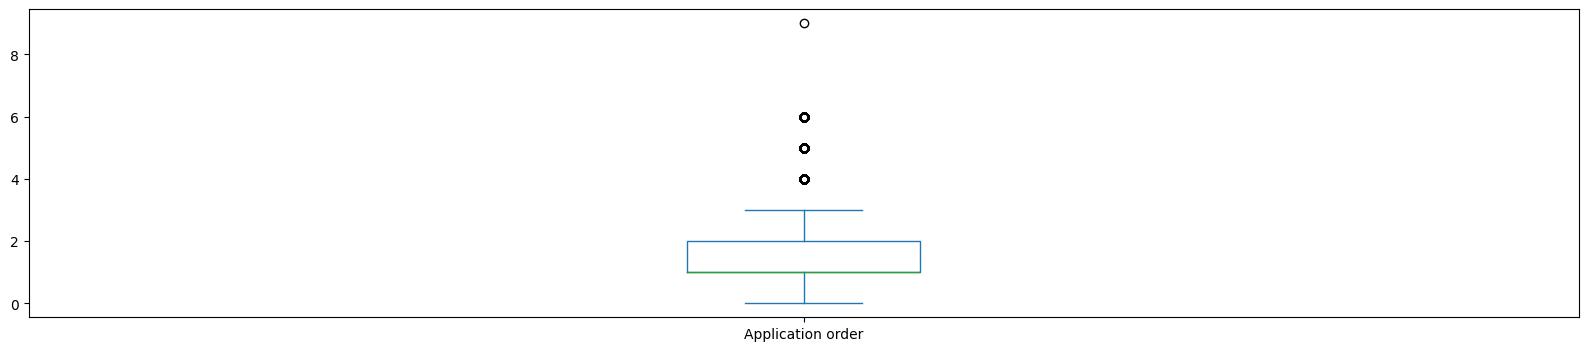

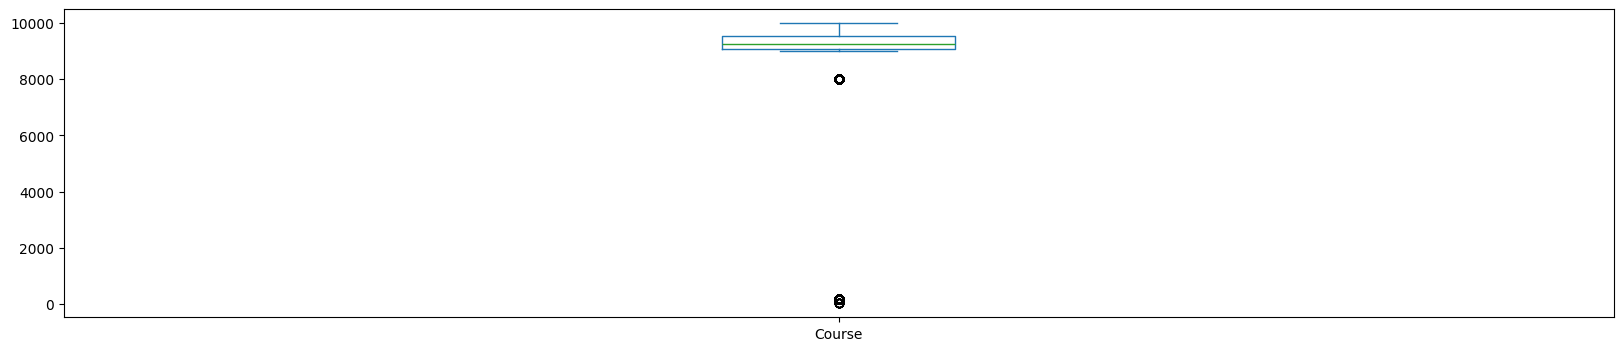

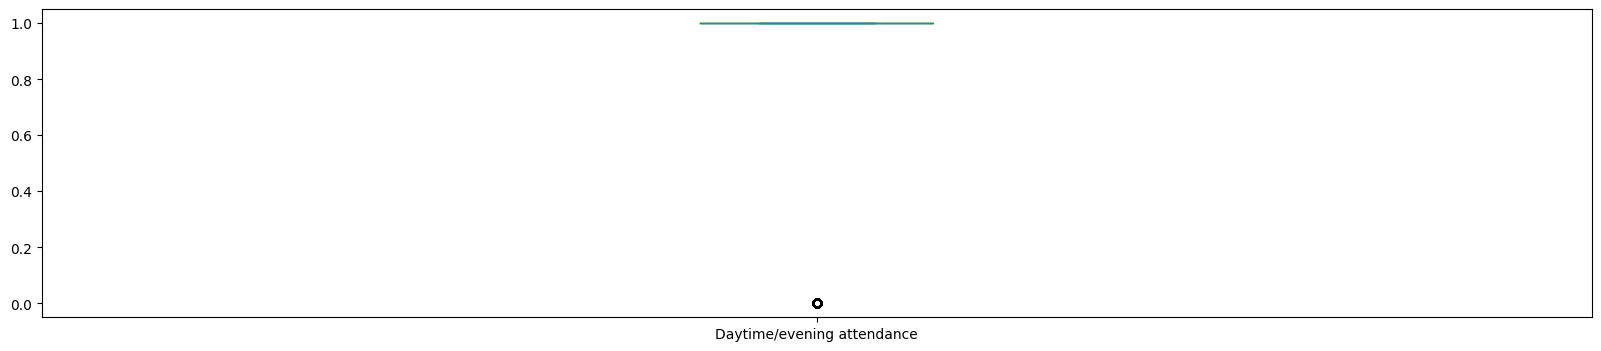

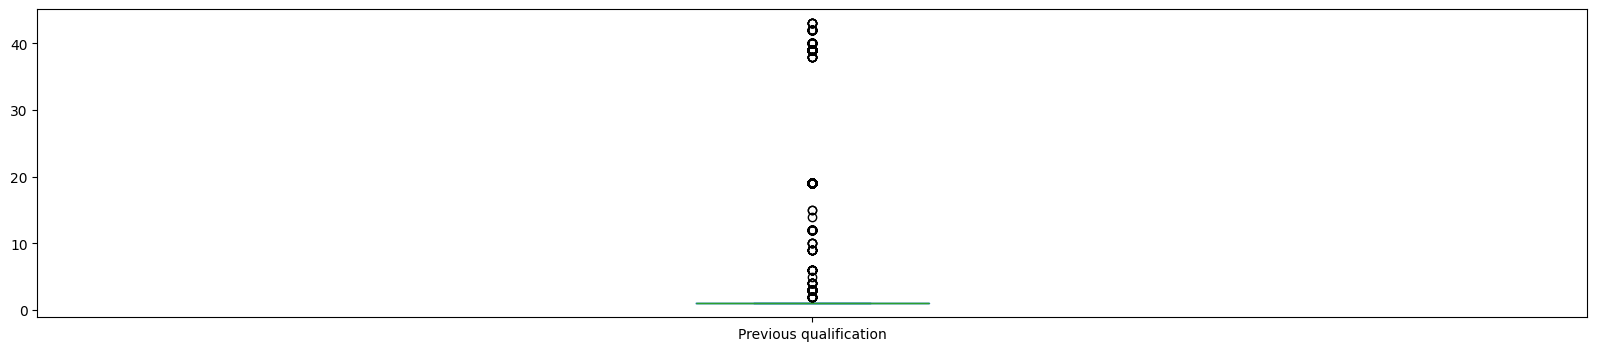

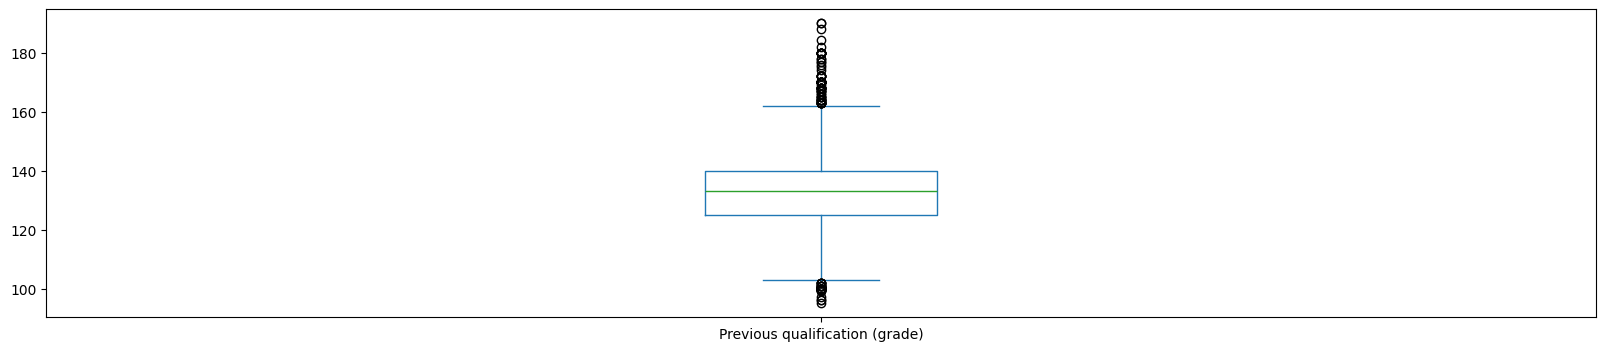

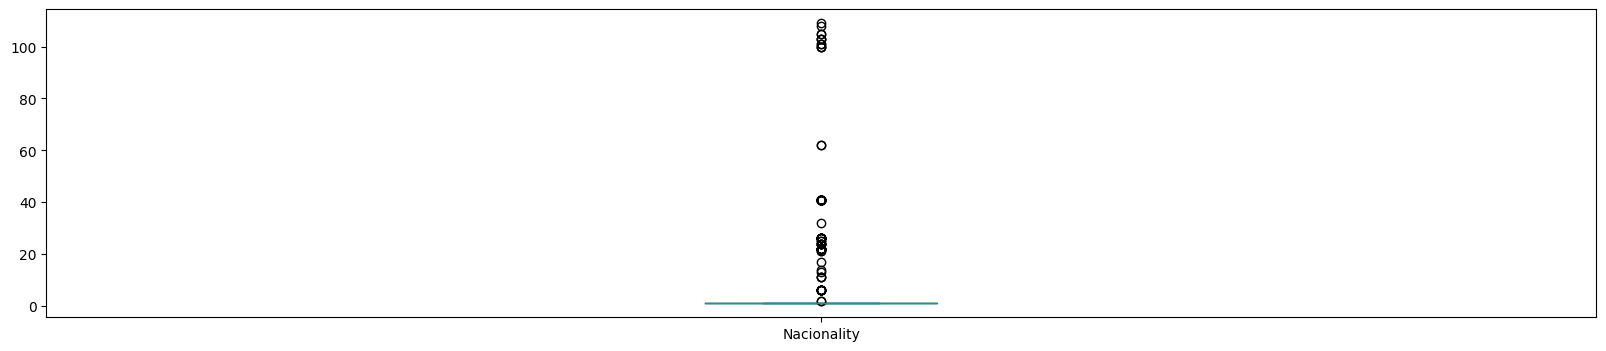

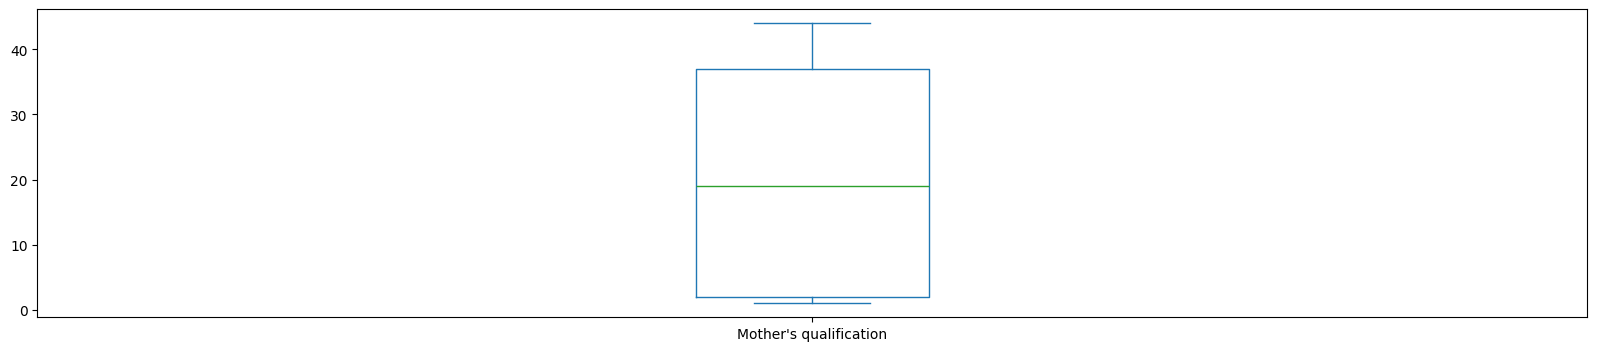

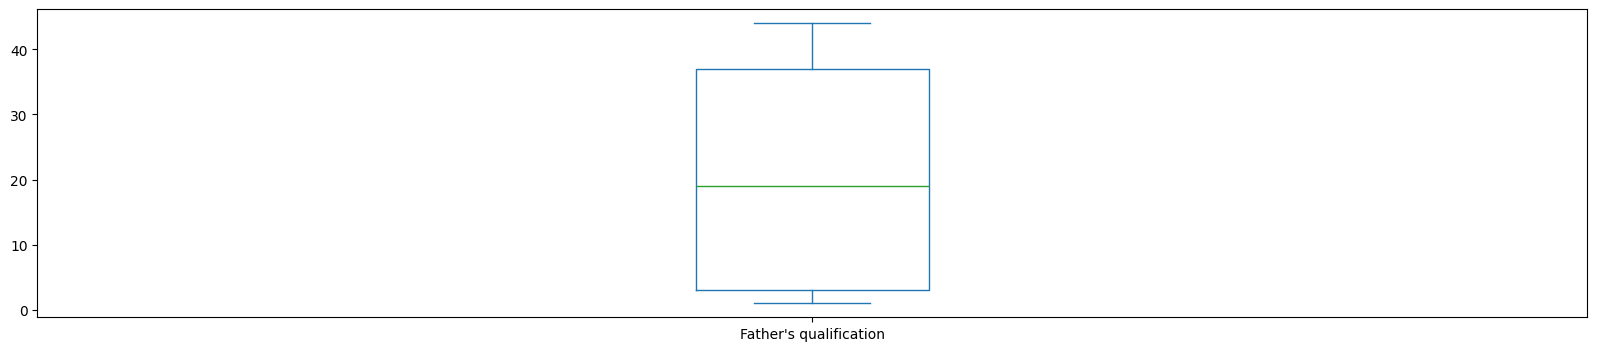

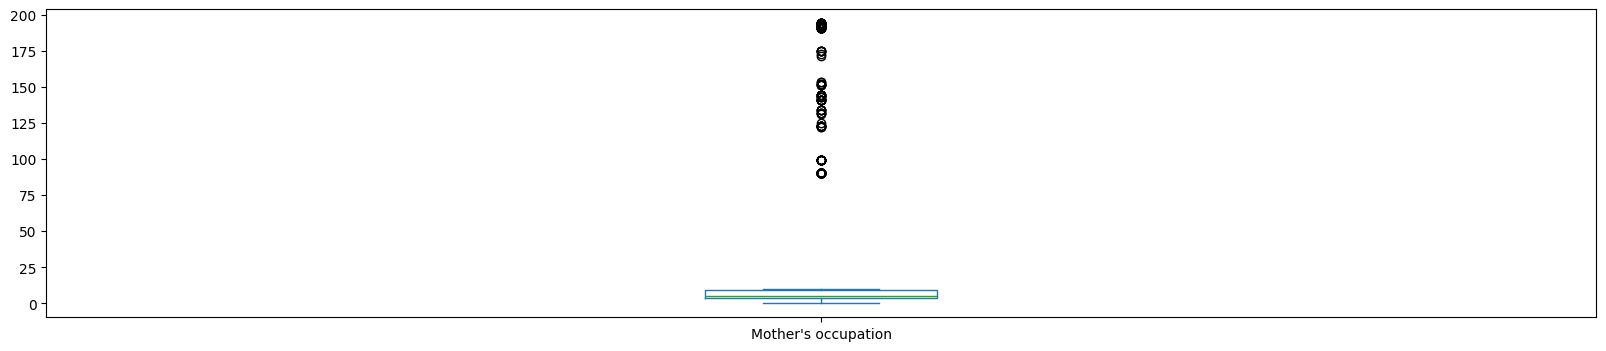

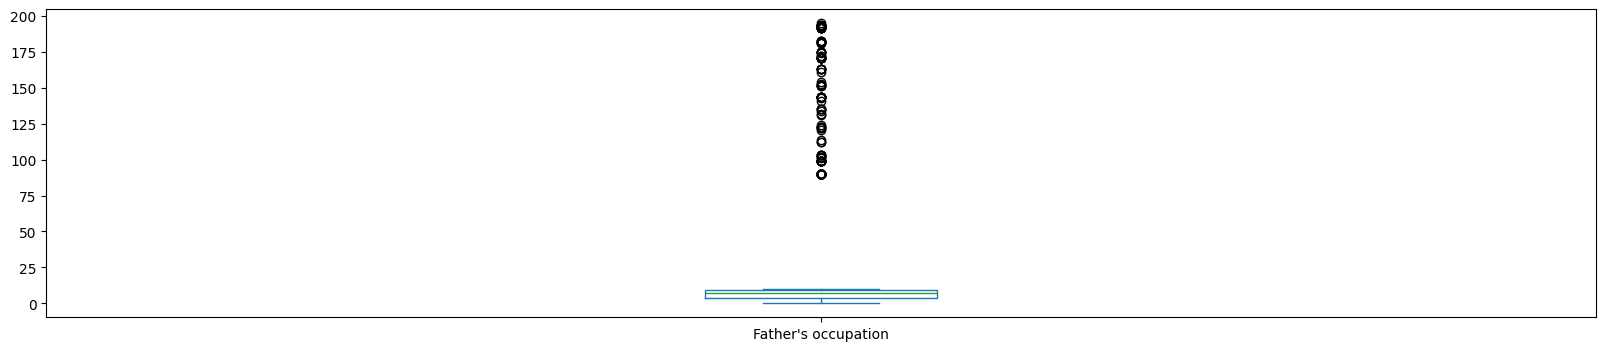

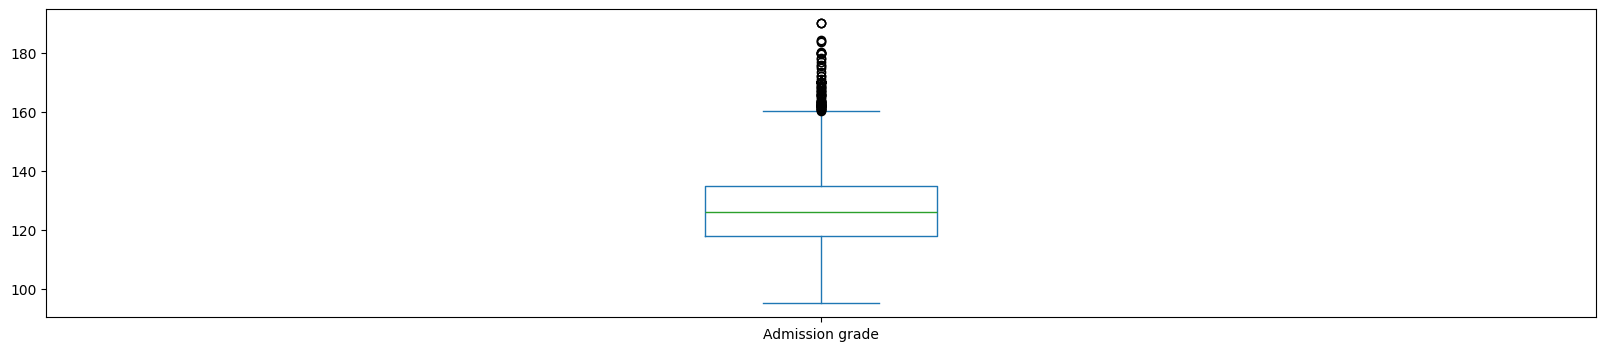

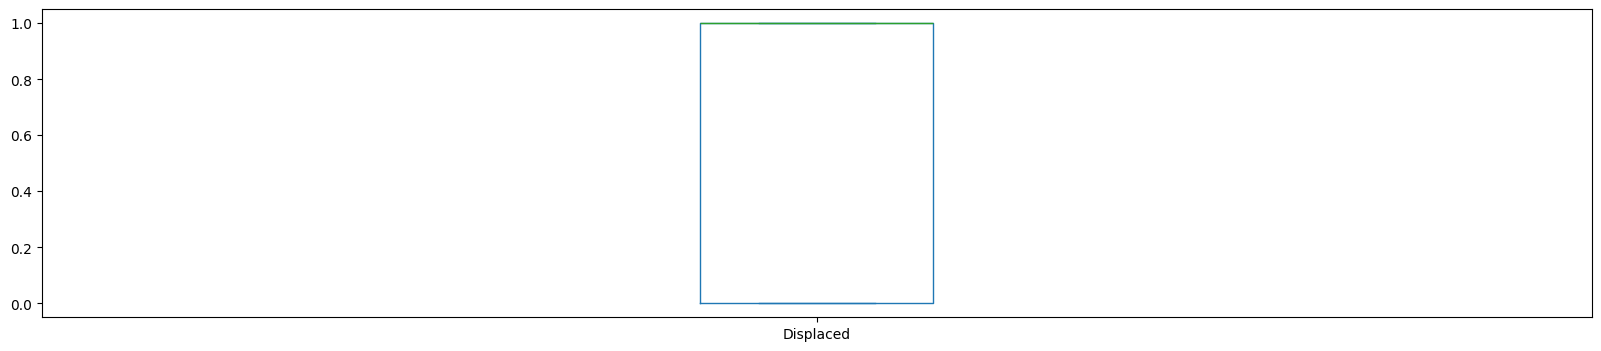

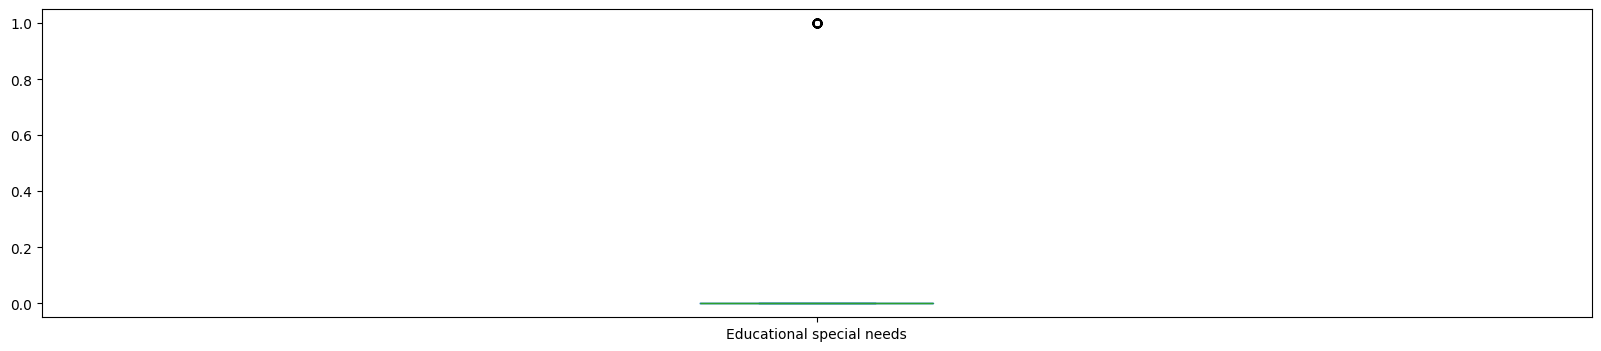

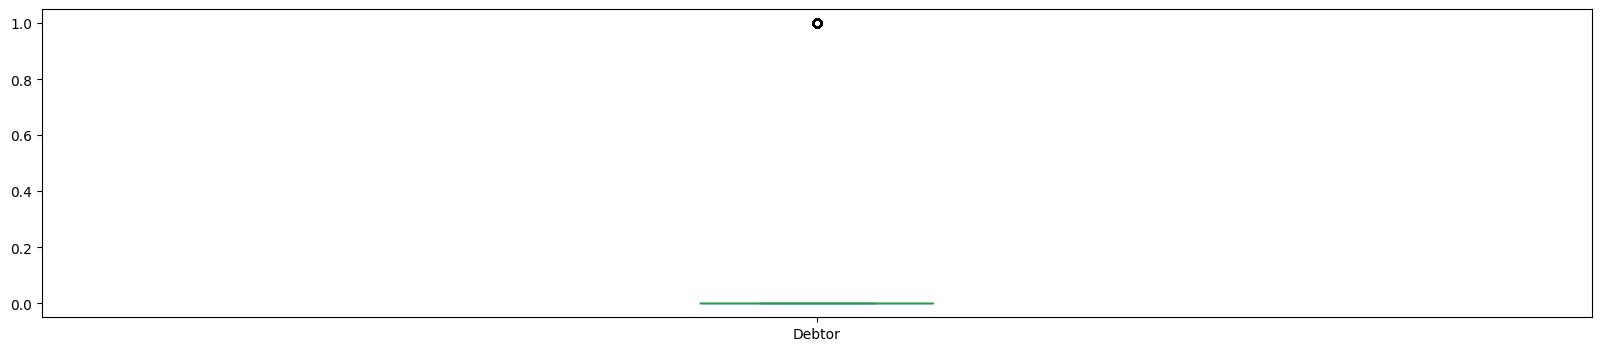

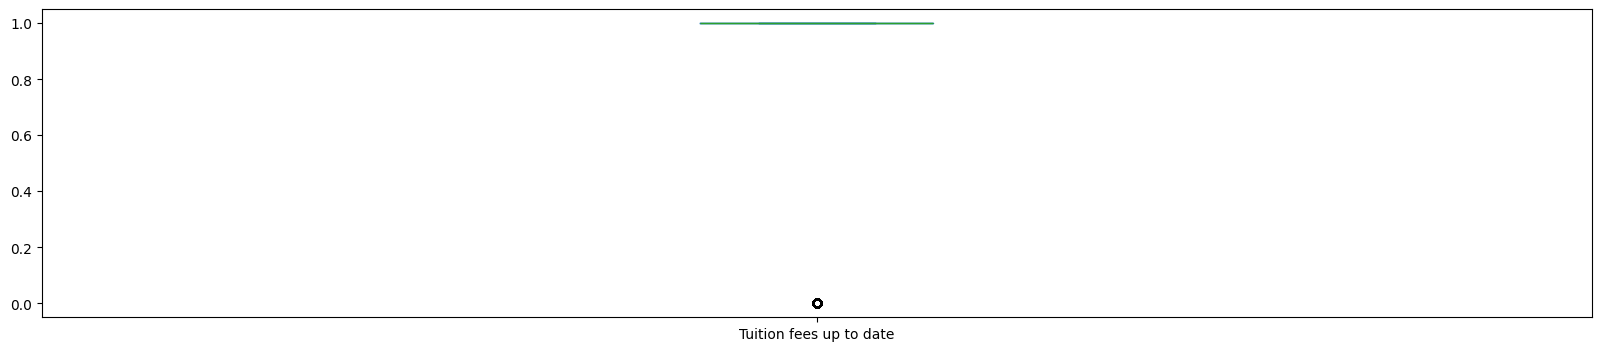

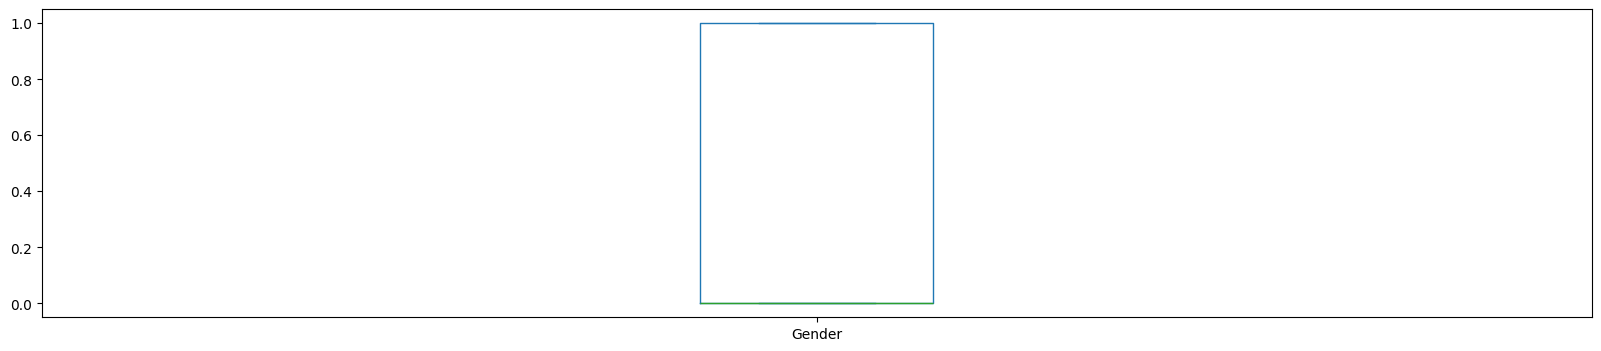

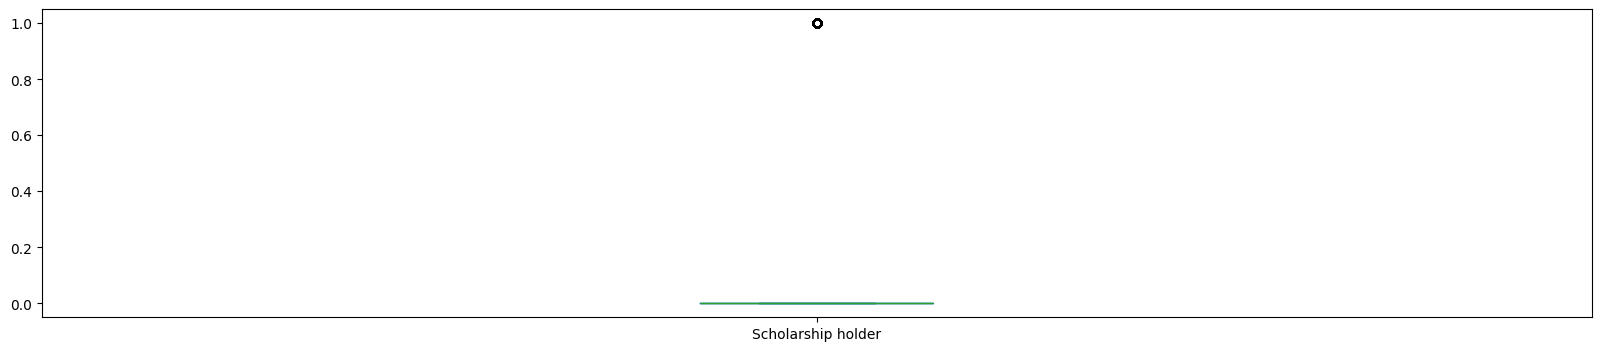

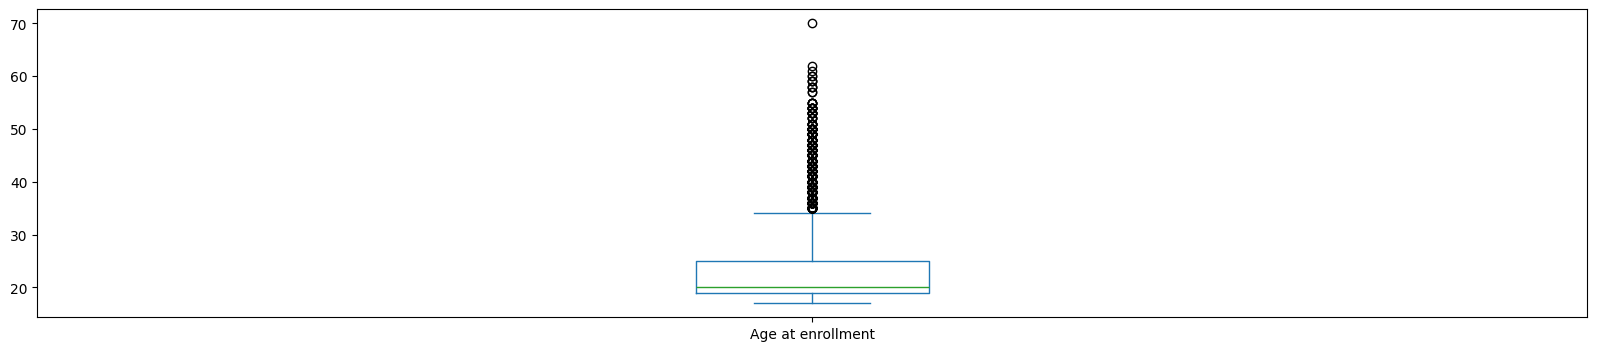

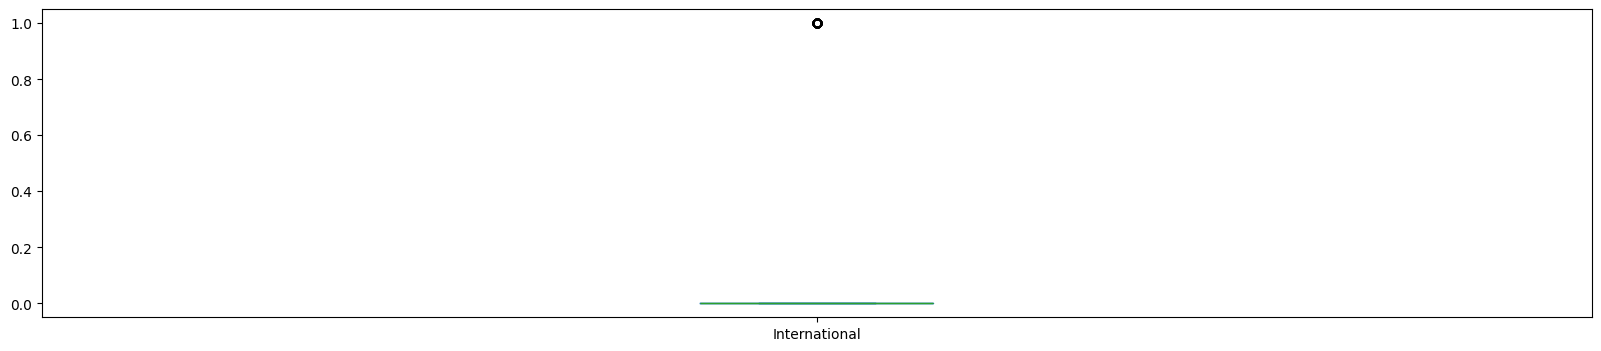

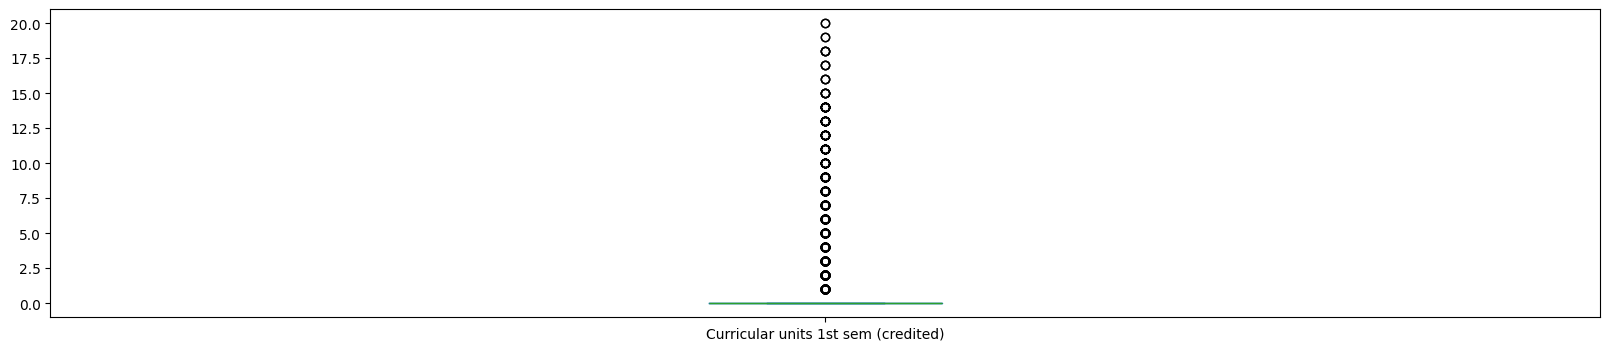

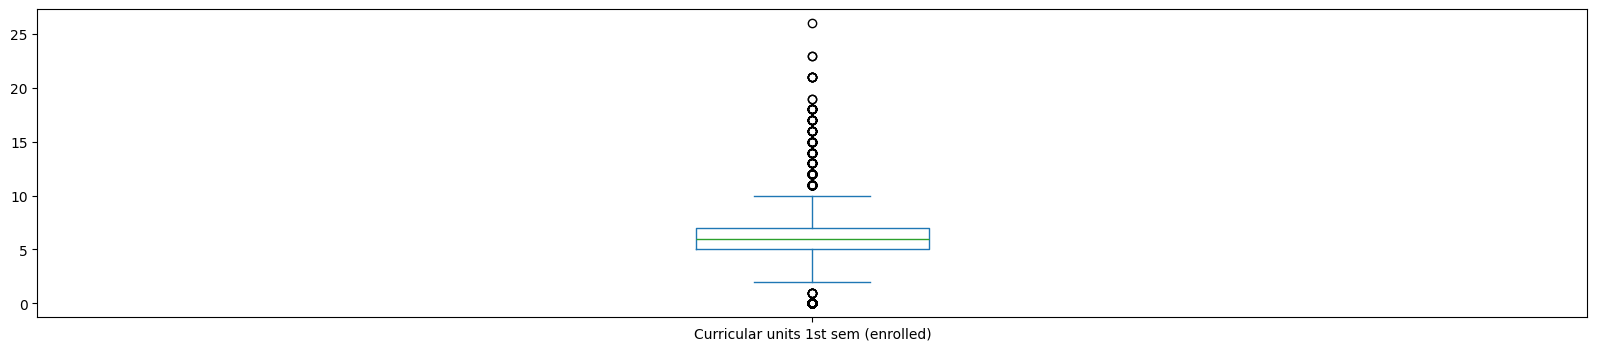

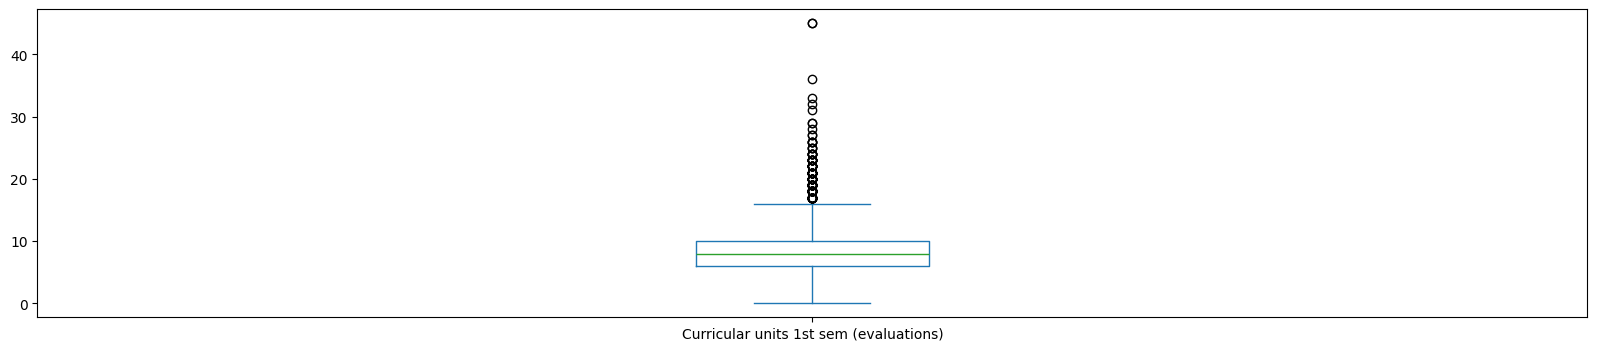

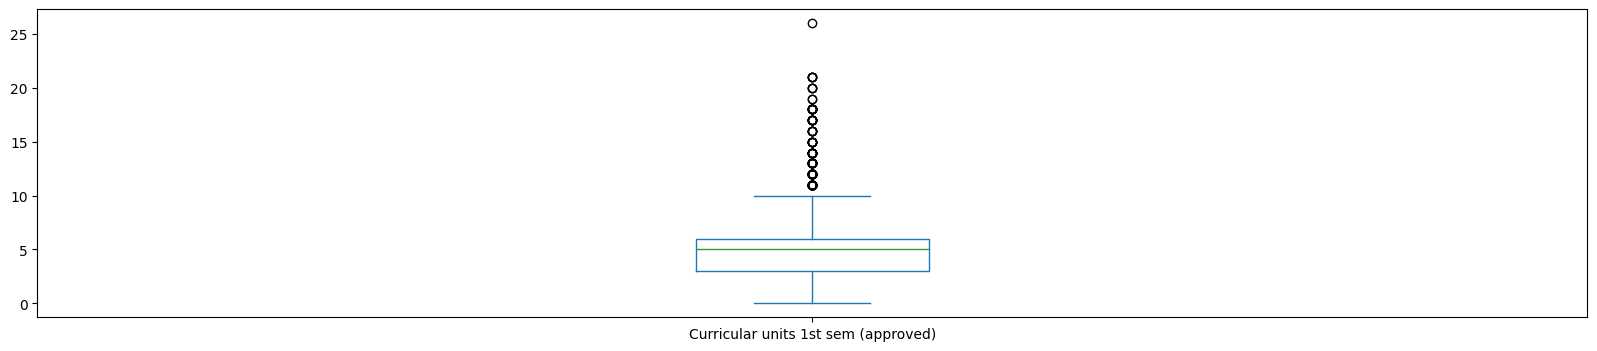

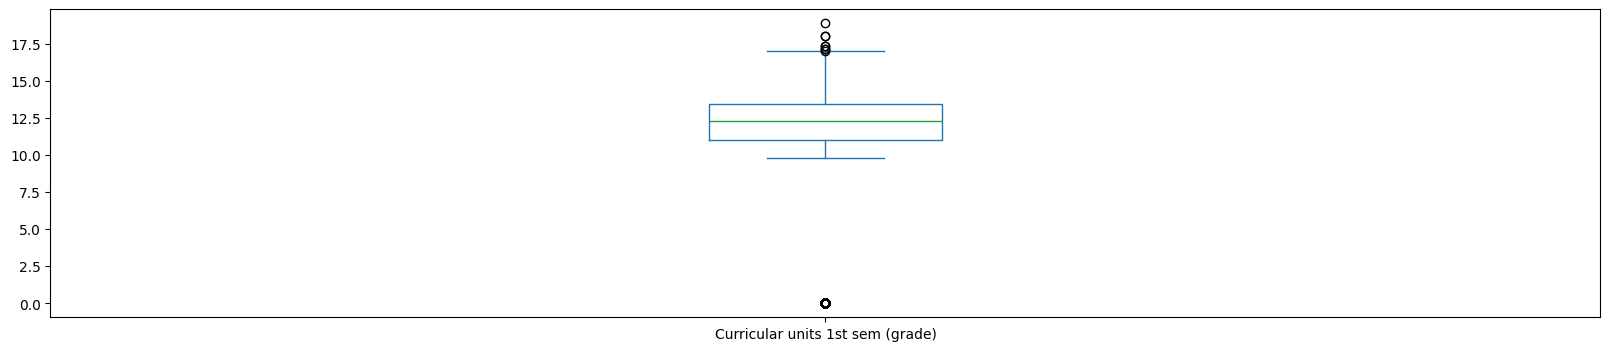

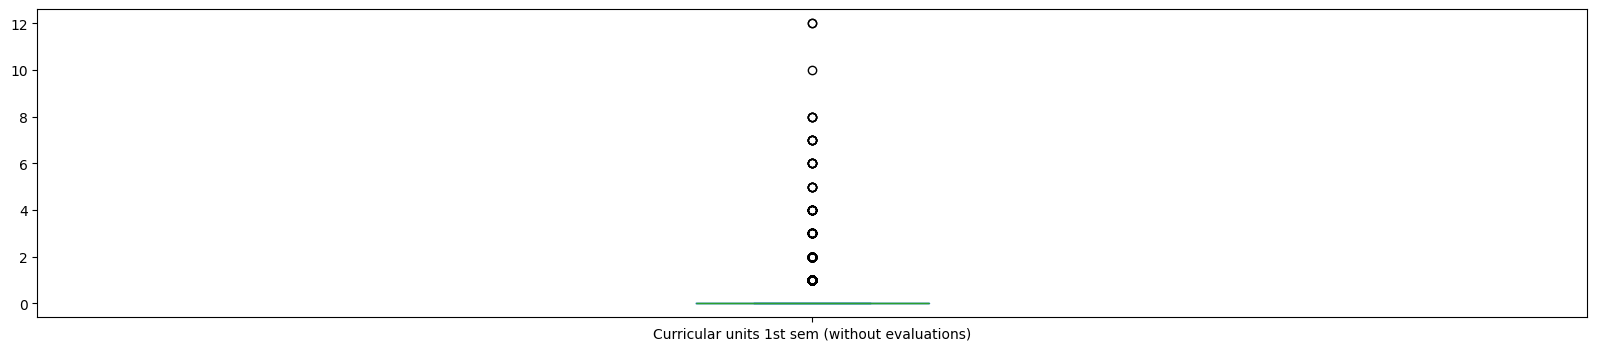

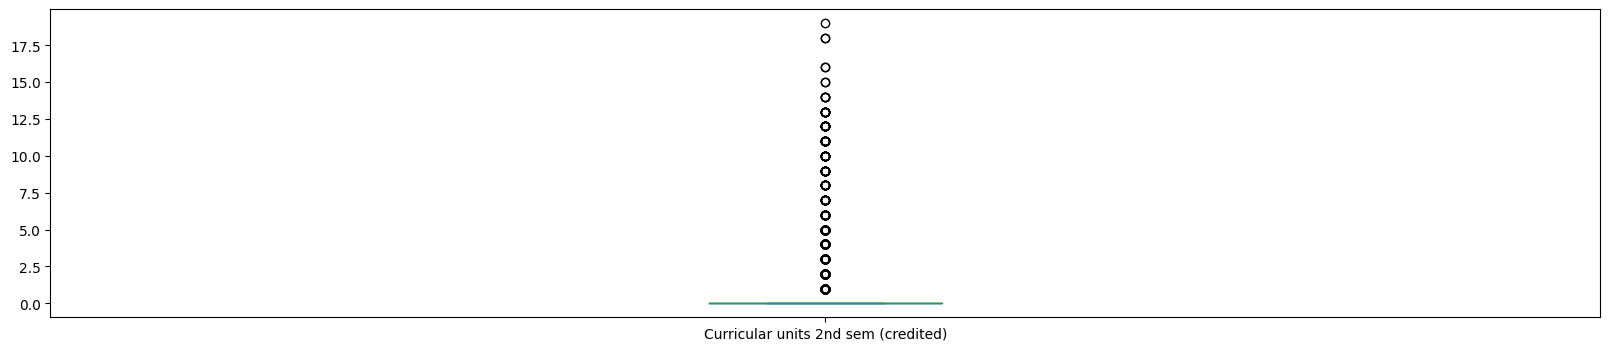

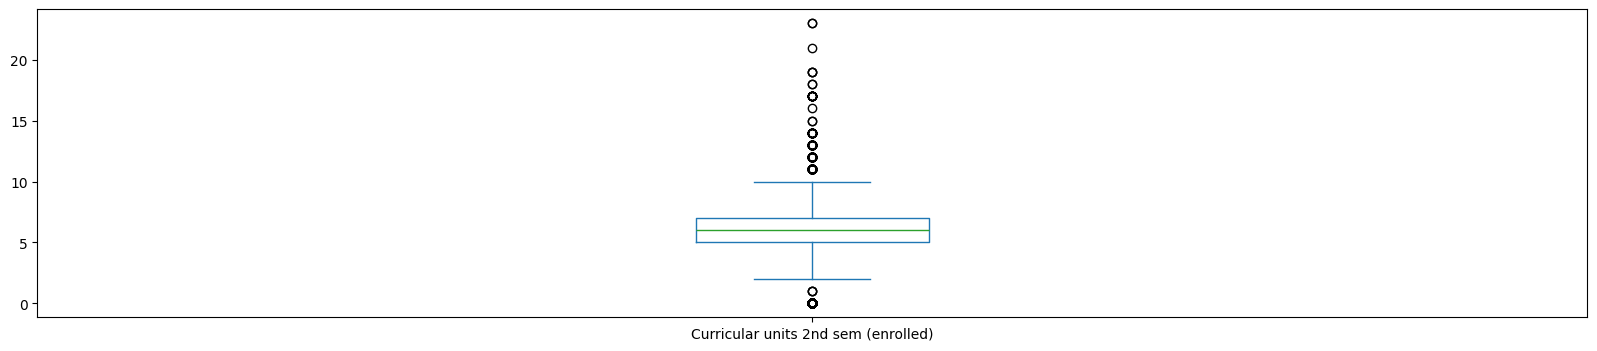

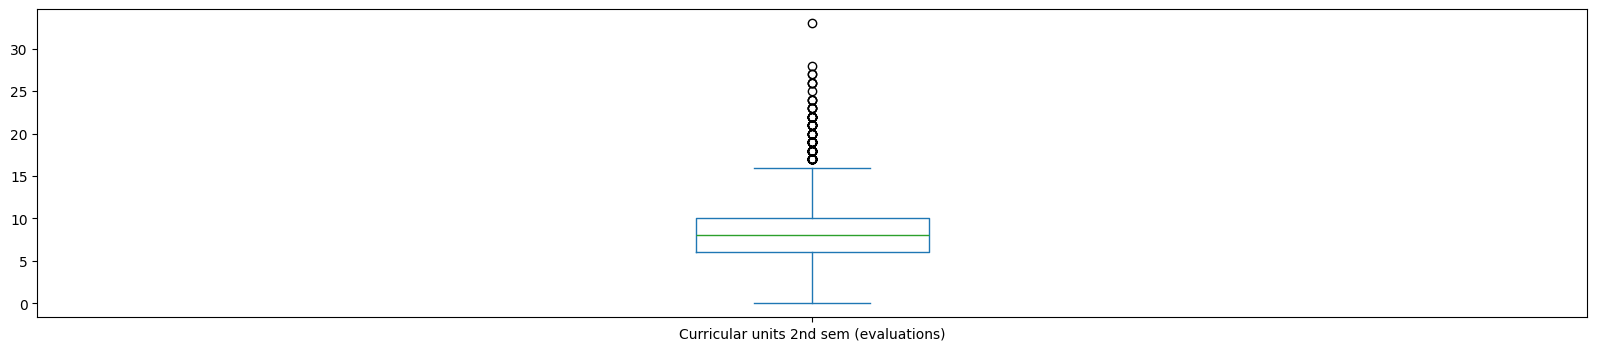

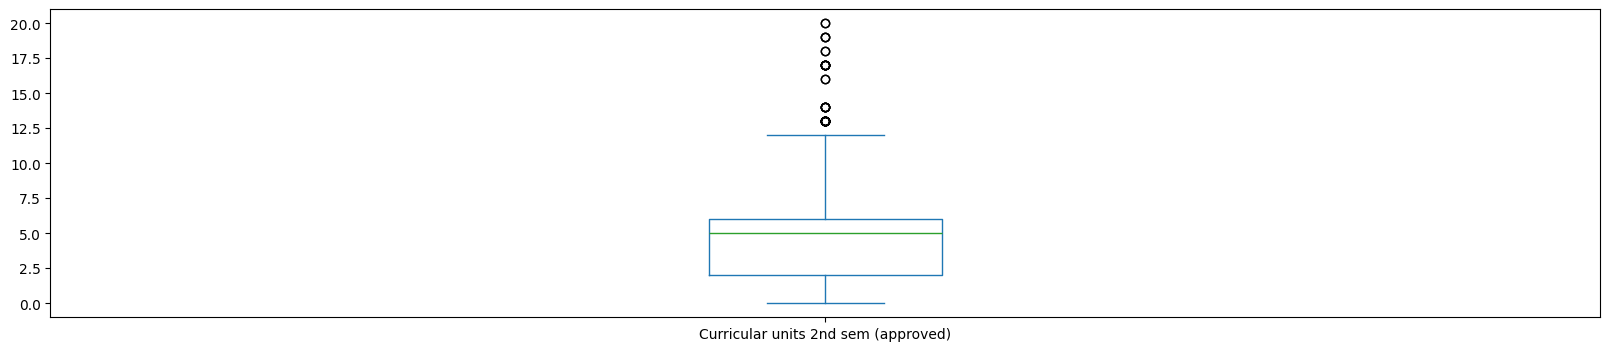

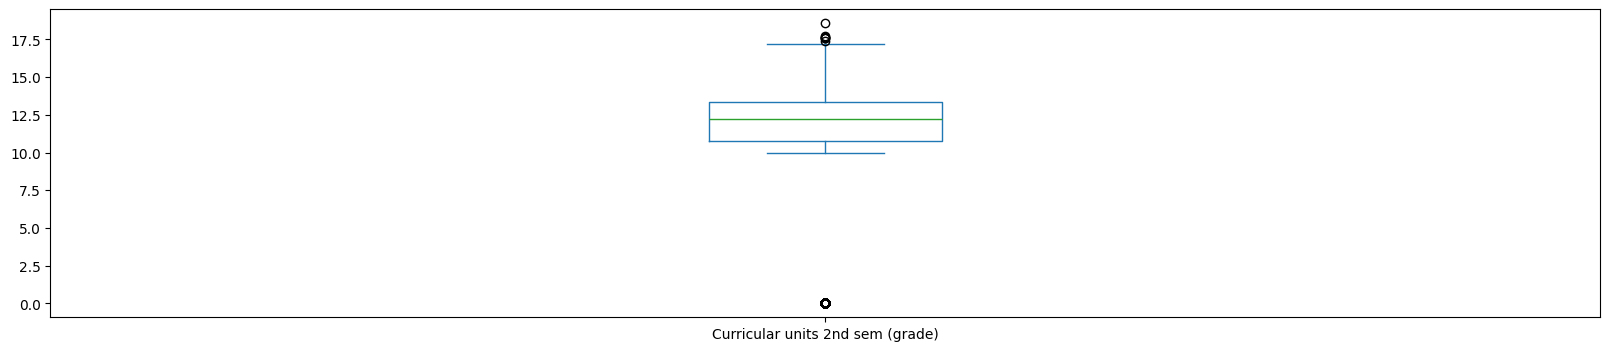

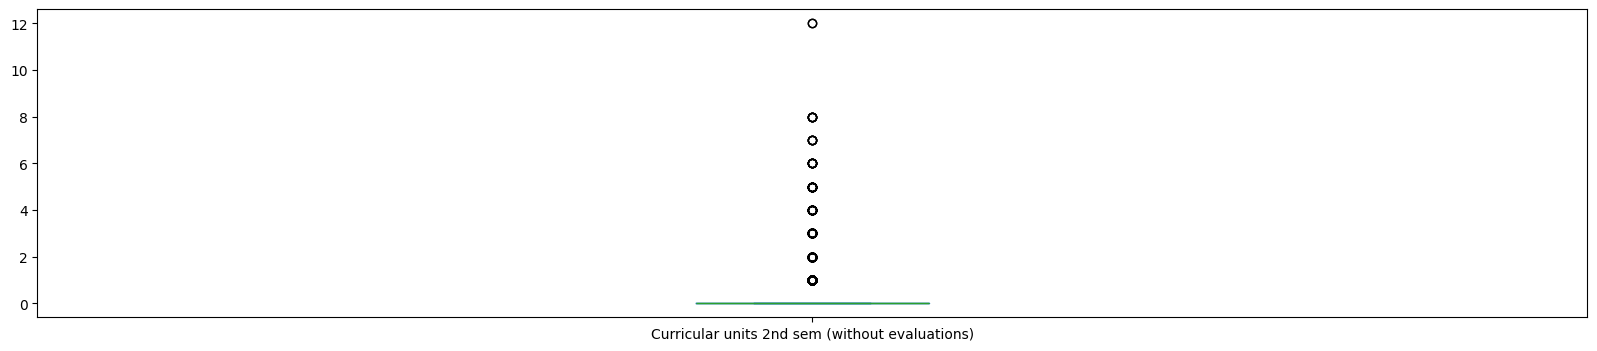

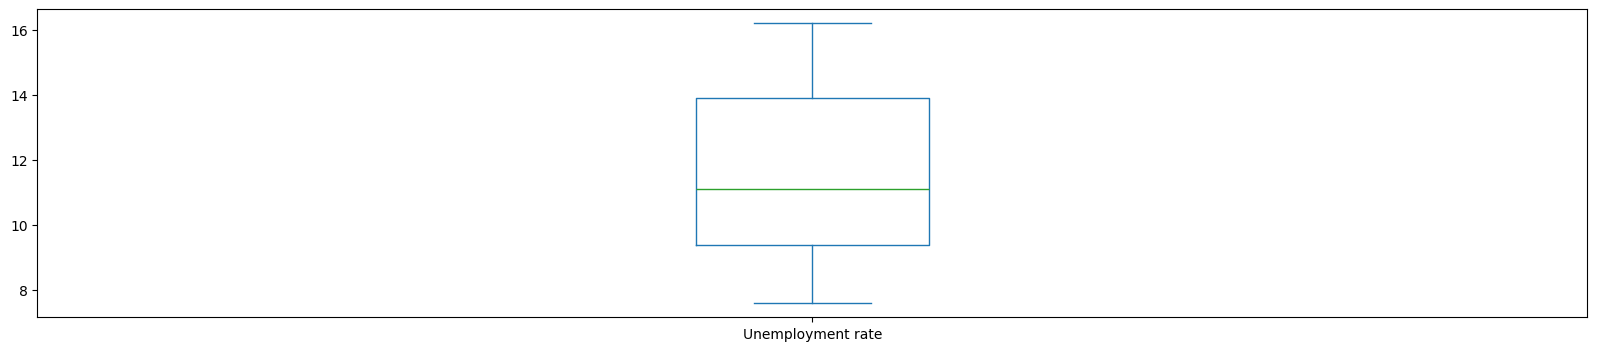

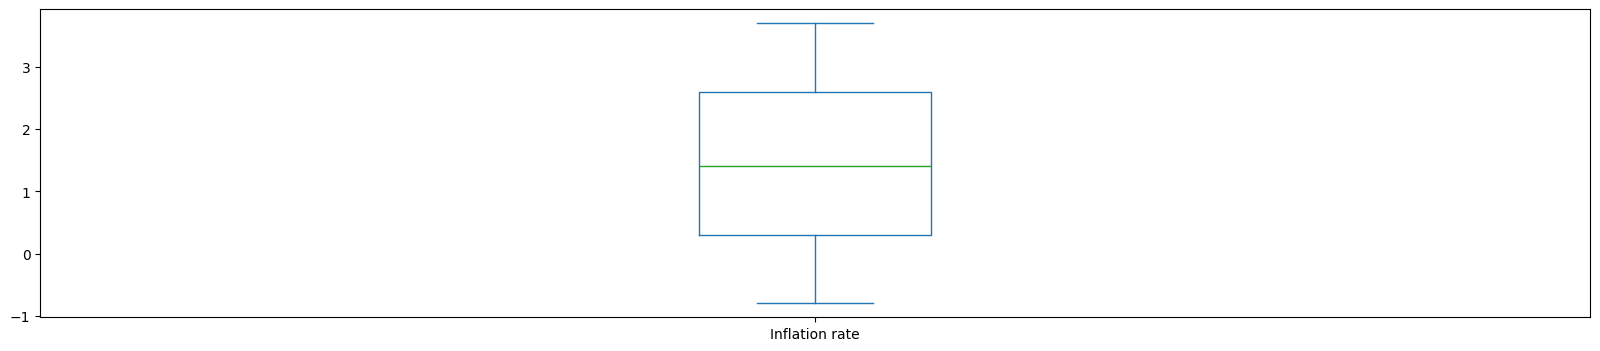

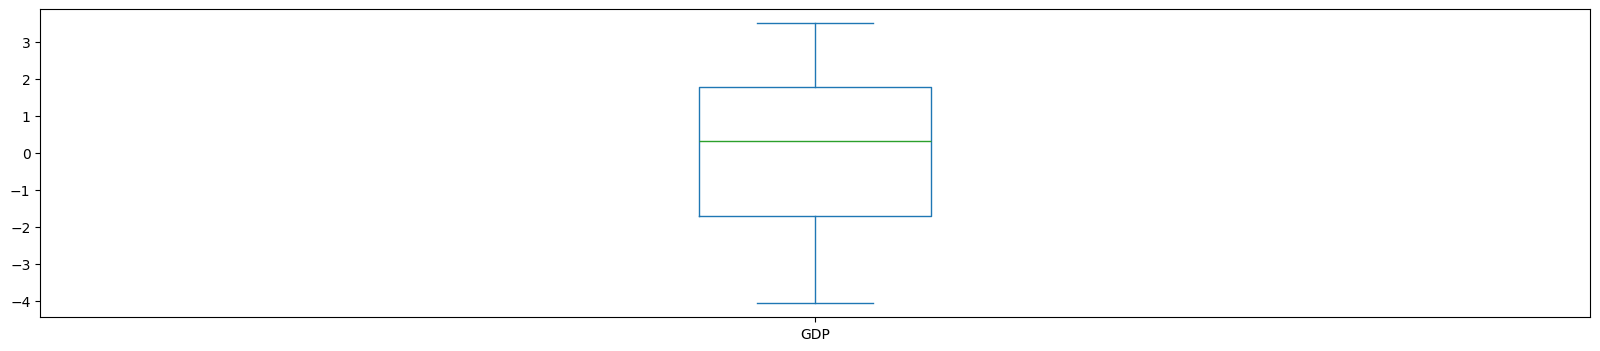

In [55]:
for box in numCols:
    plt.figure(figsize=(20,4))
    studentOutcome[box].plot(kind="box")

In [13]:
# check skewnesss
for skew in studentOutcome.columns:
    if skew!="Target":
       skewness=studentOutcome[skew].skew()
       print(f"{skew}   {skewness}")

Marital status   0.0
Application mode   0.39303572000104375
Application order   1.2496863440610875
Course   -0.5359952962499155
Daytime/evening attendance   0.0
Previous qualification   0.0
Previous qualification (grade)   0.12894032321492305
Nacionality   0.0
Mother's qualification   0.0019784778637636728
Father's qualification   -0.2986972192307779
Mother's occupation   0.6922813028121333
Father's occupation   0.55455450709097
Admission grade   0.3089951461339683
Displaced   -0.1944678977534714
Educational special needs   0.0
Debtor   0.0
Tuition fees up to date   0.0
Gender   0.6212791167838527
Scholarship holder   0.0
Age at enrollment   1.1984846454158213
International   0.0
Curricular units 1st sem (credited)   0.0
Curricular units 1st sem (enrolled)   0.21077462740508612
Curricular units 1st sem (evaluations)   -0.12470826182414994
Curricular units 1st sem (approved)   -0.22363644148023495
Curricular units 1st sem (grade)   -0.7426485933171549
Curricular units 1st sem (without e

In [56]:
# Data splitting 
x=studentOutcome.drop(columns=["Target"])
y=studentOutcome["Target"]
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=43,random_state=43)

In [57]:
xTest

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2507,1,39,1,8014,0,1,120.0,1,38,37,...,0,1,6,7,5,12.000000,0,13.9,-0.3,0.79
4319,1,17,1,9773,1,1,136.0,1,19,38,...,0,0,6,6,6,13.166667,0,12.7,3.7,-1.70
2659,1,1,1,9254,1,1,125.0,1,37,37,...,0,0,6,6,5,12.200000,0,11.1,0.6,2.02
1365,1,39,1,9670,1,9,133.1,1,6,22,...,0,0,5,5,0,0.000000,5,9.4,-0.8,-3.12
1761,1,17,1,171,1,1,140.0,41,1,1,...,0,0,0,0,0,0.000000,0,12.7,3.7,-1.70
3720,1,44,1,9003,1,1,120.0,1,1,3,...,0,0,6,19,0,0.000000,0,16.2,0.3,-0.92
3864,1,43,1,9085,1,1,110.0,1,3,19,...,0,0,6,8,2,11.500000,0,13.9,-0.3,0.79
972,2,39,2,9119,1,19,133.1,1,37,37,...,0,0,5,5,0,0.000000,0,9.4,-0.8,-3.12
1067,1,1,1,9147,1,1,130.0,1,37,38,...,2,0,5,7,5,11.400000,0,15.5,2.8,-4.06
3524,2,39,1,9991,0,1,150.0,1,1,4,...,0,0,5,5,5,14.600000,0,12.7,3.7,-1.70


In [58]:
# implement PIPELINE
pipelineNum=Pipeline(steps=[
    ("Handle Skewness",PowerTransformer()),
    ("Normalize",StandardScaler())
]
                    )

Transformer=ColumnTransformer(
    [
        ("preprocessor",pipelineNum,numCols)
            # ("preprocessorText",numText,pipelineNum)
    ]
)

In [59]:
xTrain=Transformer.fit_transform(xTrain)


In [60]:
xTrain=pd.DataFrame(xTrain,columns=Transformer.get_feature_names_out())

In [61]:
xTrain

,preprocessor__Marital status,preprocessor__Application mode,preprocessor__Application order,preprocessor__Course,preprocessor__Daytime/evening attendance,preprocessor__Previous qualification,preprocessor__Previous qualification (grade),preprocessor__Nacionality,preprocessor__Mother's qualification,preprocessor__Father's qualification,...,preprocessor__Curricular units 1st sem (without evaluations),preprocessor__Curricular units 2nd sem (credited),preprocessor__Curricular units 2nd sem (enrolled),preprocessor__Curricular units 2nd sem (evaluations),preprocessor__Curricular units 2nd sem (approved),preprocessor__Curricular units 2nd sem (grade),preprocessor__Curricular units 2nd sem (without evaluations),preprocessor__Unemployment rate,preprocessor__Inflation rate,preprocessor__GDP
0,-0.357310,1.073368,-0.648307,0.657057,0.349957,2.382288,0.072081,-0.159734,-1.340175,-0.048557,...,-0.265262,-0.370164,-0.551683,-0.755440,-0.052531,0.065934,-0.259297,-0.787133,-1.662821,-1.295140
1,-0.357310,0.360788,1.771394,0.067443,0.349957,-0.434634,-0.875345,-0.159734,-1.340175,-0.048557,...,-0.265262,-0.370164,-0.095809,-2.135858,-1.591717,-1.901827,-0.259297,-0.787133,-1.662821,-1.295140
2,-0.357310,1.328893,-0.648307,-0.074410,0.349957,-0.434634,-0.164444,-0.159734,-1.340175,-1.479429,...,-0.265262,-0.370164,-0.551683,0.746186,-0.386438,0.437123,-0.259297,-0.096880,-0.355550,0.902254
3,-0.357310,-1.175542,-0.648307,-0.174083,0.349957,-0.434634,-1.371036,-0.159734,0.254372,-1.479429,...,3.769794,-0.370164,-0.095809,0.007457,0.565104,0.226943,-0.259297,0.895977,-1.141163,0.219094
4,-0.357310,0.406111,-0.648307,0.489329,0.349957,-0.434634,0.072081,-0.159734,-1.000633,-0.048557,...,-0.265262,-0.370164,0.356049,0.746186,0.263393,0.414675,-0.259297,-1.006170,0.225331,1.827916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,-0.357310,1.073368,-0.648307,-0.096588,0.349957,1.957611,1.295148,-0.159734,-1.000633,-1.479429,...,-0.265262,-0.370164,-0.551683,-0.755440,-1.591717,-1.901827,-0.259297,0.489230,1.619014,-0.825142
4377,-0.357310,0.360788,1.686801,-0.074410,0.349957,-0.434634,-0.956694,-0.159734,1.057148,-0.048557,...,-0.265262,-0.370164,-0.551683,-0.755440,0.263393,0.582559,-0.259297,-1.006170,0.225331,1.827916
4378,2.797516,1.073368,-0.648307,-0.110887,0.349957,-0.434634,-1.798750,-0.159734,1.021837,0.917588,...,-0.265262,-0.370164,-0.551683,0.255968,-1.591717,-1.901827,-0.259297,-1.006170,0.225331,1.827916
4379,-0.357310,0.406111,1.771394,-0.110887,0.349957,-0.434634,0.289729,-0.159734,-1.000633,-1.356481,...,-0.265262,-0.370164,-0.551683,0.255968,0.263393,1.011851,-0.259297,0.383394,-0.434185,0.768110


In [62]:
xTest=Transformer.transform(xTest)

In [63]:
xTest=pd.DataFrame(xTest,columns=Transformer.get_feature_names_out())

In [64]:
xTest

,preprocessor__Marital status,preprocessor__Application mode,preprocessor__Application order,preprocessor__Course,preprocessor__Daytime/evening attendance,preprocessor__Previous qualification,preprocessor__Previous qualification (grade),preprocessor__Nacionality,preprocessor__Mother's qualification,preprocessor__Father's qualification,...,preprocessor__Curricular units 1st sem (without evaluations),preprocessor__Curricular units 2nd sem (credited),preprocessor__Curricular units 2nd sem (enrolled),preprocessor__Curricular units 2nd sem (evaluations),preprocessor__Curricular units 2nd sem (approved),preprocessor__Curricular units 2nd sem (grade),preprocessor__Curricular units 2nd sem (without evaluations),preprocessor__Unemployment rate,preprocessor__Inflation rate,preprocessor__GDP
0,-0.357310,1.073368,-0.648307,-1.350078,-2.857494,-0.434634,-0.956694,-0.159734,1.057148,0.917588,...,-0.265262,2.641475,-0.095809,-0.243686,0.263393,0.259670,-0.259297,0.895977,-1.141163,0.219094
1,-0.357310,0.360788,-0.648307,0.812695,0.349957,-0.434634,0.289729,-0.159734,0.254372,0.965966,...,-0.265262,-0.370164,-0.095809,-0.497827,0.565104,0.573380,-0.259297,0.489230,1.619014,-0.825142
2,-0.357310,-1.175542,-0.648307,0.067443,0.349957,-0.434634,-0.554778,-0.159734,1.021837,0.917588,...,-0.265262,-0.370164,-0.095809,-0.497827,0.263393,0.312394,-0.259297,-0.096880,-0.355550,0.902254
3,-0.357310,1.073368,-0.648307,0.657057,0.349957,2.363022,0.072081,-0.159734,-0.650558,0.128432,...,-0.265262,-0.370164,-0.551683,-0.755440,-1.591717,-1.901827,3.856661,-0.787133,-1.662821,-1.295140
4,-0.357310,0.360788,-0.648307,-3.617685,0.349957,-0.434634,0.584432,6.260657,-1.340175,-1.479429,...,-0.265262,-0.370164,-2.935801,-2.135858,-1.591717,-1.901827,-0.259297,0.489230,1.619014,-0.825142
5,-0.357310,1.186705,-0.648307,-0.259191,0.349957,-0.434634,-0.956694,-0.159734,-1.340175,-1.246990,...,-0.265262,-0.370164,-0.095809,2.640551,-1.591717,-1.901827,-0.259297,1.611515,-0.596770,-0.541011
6,-0.357310,1.164909,-0.648307,-0.154823,0.349957,-0.434634,-1.798750,-0.159734,-1.000633,-0.048557,...,-0.265262,-0.370164,-0.095809,0.007457,-0.744383,0.129810,-0.259297,0.895977,-1.141163,0.219094
7,2.797516,1.073368,1.044718,-0.110887,0.349957,2.395236,0.072081,-0.159734,1.021837,0.917588,...,-0.265262,-0.370164,-0.551683,-0.755440,-1.591717,-1.901827,-0.259297,-0.787133,-1.662821,-1.295140
8,-0.357310,-1.175542,-0.648307,-0.074410,0.349957,-0.434634,-0.164444,-0.159734,1.021837,0.965966,...,3.769921,-0.370164,-0.551683,-0.243686,0.263393,0.104174,-0.259297,1.401751,1.108110,-1.583656
9,2.797516,1.073368,-0.648307,1.155186,-2.857494,-0.434634,1.295148,-0.159734,-1.340175,-1.146527,...,-0.265262,-0.370164,-0.551683,-0.755440,0.263393,0.978624,-0.259297,0.489230,1.619014,-0.825142


In [ ]:
# Encode Target

In [67]:
encoder=LabelEncoder()
yTrain=encoder.fit_transform(yTrain)

In [68]:
yTest=encoder.fit_transform(yTest)

In [69]:
yTest

array([2, 2, 0, 0, 0, 1, 0, 0, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0, 1, 2, 0, 1,
       1, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 1, 1, 2, 2, 2, 2])

In [ ]:
# 

In [161]:
catModel = XGBClassifier(
    learning_rate = 0.1,
    max_depth     = 5,
    n_estimators  = 390,
    random_state  = 50
)

catModel.fit(xTrain, yTrain)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [162]:
prediction=catModel.predict(xTest)

In [163]:
precisionScore = precision_score(yTest, prediction, average='weighted')
precisionScore

0.790033222591362

In [ ]:
# prediction
prediction=catModel.predict(xTest)

In [165]:
# Model Evaluation
confusionMatrix=confusion_matrix(yTest,prediction)
confusionMatrix

array([[11,  1,  3],
       [ 0,  4,  4],
       [ 0,  2, 18]])

In [166]:
recallScore=recall_score(yTest,prediction,average="weighted")

In [167]:
recallScore

0.7674418604651163

In [179]:
report=classification_report(yTest,prediction,target_names=encoder.classes_,output_dict=True)

In [180]:
report

{'Dropout': {'precision': 1.0,
  'recall': 0.7333333333333333,
  'f1-score': 0.8461538461538461,
  'support': 15.0},
 'Enrolled': {'precision': 0.5714285714285714,
  'recall': 0.5,
  'f1-score': 0.5333333333333333,
  'support': 8.0},
 'Graduate': {'precision': 0.72,
  'recall': 0.9,
  'f1-score': 0.8,
  'support': 20.0},
 'accuracy': 0.7674418604651163,
 'macro avg': {'precision': 0.7638095238095238,
  'recall': 0.7111111111111111,
  'f1-score': 0.7264957264957266,
  'support': 43.0},
 'weighted avg': {'precision': 0.790033222591362,
  'recall': 0.7674418604651163,
  'f1-score': 0.7664877757901014,
  'support': 43.0}}

In [182]:
reportFrame=pd.DataFrame(report).transpose()

In [184]:
# classificatiion Report
reportFrame

,precision,recall,f1-score,support
Dropout,1.000000,0.733333,0.846154,15.000000
Enrolled,0.571429,0.500000,0.533333,8.000000
Graduate,0.720000,0.900000,0.800000,20.000000
accuracy,0.767442,0.767442,0.767442,0.767442
macro avg,0.763810,0.711111,0.726496,43.000000
weighted avg,0.790033,0.767442,0.766488,43.000000


In [185]:
# computer probabability
proba=catModel.predict_proba(xTrain)
proba

array([[9.7680330e-01, 1.7870894e-02, 5.3258049e-03],
       [9.9764436e-01, 2.2584433e-03, 9.7222794e-05],
       [5.9829529e-02, 8.7331170e-01, 6.6858694e-02],
       ...,
       [9.5506030e-01, 4.4016764e-02, 9.2293951e-04],
       [8.2576990e-02, 7.2020555e-01, 1.9721743e-01],
       [8.0500758e-04, 4.2191608e-04, 9.9877304e-01]],
      shape=(4381, 3), dtype=float32)

In [189]:
# probability table
proTable=pd.DataFrame(proba,columns=encoder.classes_)
proTable

,Dropout,Enrolled,Graduate
0,0.976803,0.017871,0.005326
1,0.997644,0.002258,0.000097
2,0.059830,0.873312,0.066859
3,0.038126,0.083552,0.878322
4,0.046642,0.223916,0.729442
...,...,...,...
4376,0.998674,0.000865,0.000462
4377,0.001415,0.000944,0.997642
4378,0.955060,0.044017,0.000923
4379,0.082577,0.720206,0.197217
